# Automated Computation of High Tibial Osteotomy Correction Angles

This project aims to automate the detection of key anatomical landmarks (such as the femur head, tibia top, and tibia bottom) in long-leg radiographs (X-rays). By accurately locating these components using a YOLO architecture, we can automatically calculate the mechanical axis and the necessary surgical correction angles for a High Tibial Osteotomy (HTO).

## Imports

Import standard data handling, computer vision, and deep learning libraries essential for PyTorch and YOLO operations.

In [1]:
import os
import json
import random
import math
import sys
import torch
import yaml
import numpy as np
import pandas as pd
from PIL import Image
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F

# Ensure CKD (Conformer Keypoint Detection) path is accessible
sys.path.append(os.path.abspath("CKD"))

from models import Conformer_tiny_patch16_keypoint
from utils import extract_coordinates

/tf/notebooks/CKD/vision_transformer.py:370: UserWarning: Overwriting vit_small_patch16_224 in registry with vision_transformer.vit_small_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/tf/notebooks/CKD/vision_transformer.py:383: UserWarning: Overwriting vit_base_patch16_224 in registry with vision_transformer.vit_base_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/tf/notebooks/CKD/vision_transformer.py:393: UserWarning: Overwriting vit_base_patch32_224 in registry with vision_transformer.vit_base_patch32_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/tf/notebooks/CKD/vision_transformer.py:402: UserWarning: Overwriting vit_base_patch16_384 in registry with vision_transformer.vit_base_patch16_384. This is b

## GPU Availability Check

Validating hardware acceleration ensures efficiently trained computer vision models. Here we check the PyTorch version and query the presence and name of any available GPUs.

In [2]:
print(f"PyTorch version: {torch.__version__}")
gpu_available = torch.cuda.is_available()
print(f"GPU available: {gpu_available}")

if gpu_available:
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu130
GPU available: True
GPU Device Name: NVIDIA GeForce RTX 4070 Laptop GPU


## Part 1: Data Preparation & Exploratory Data Analysis

Before training our YOLO model, we parse the MS COCO JSON ground truth file to structure the X-ray image data and its YOLO-format label files. We dynamically locate these files, shuffle them to prevent any ordering bias, split them into training, validation, and testing sets, and build the configuration YAML.

### Configuration

Here we define the core paths, target anatomical landmark classes, the desired split ratios across train/val/test, and other global training hyperparameters.

In [3]:
# ==============================================================================
# Global Configuration & Hyperparameters
# ==============================================================================

# Paths
DATA_DIR = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "hto_annotations.json")
OUTPUT_DIR = "yolo_data"

# Dataset Splits & Reproducibility
CLASSES = ["femur_head", "tibia_top", "tibia_bottom"]
SPLIT_RATIOS = (0.8, 0.1, 0.1)  # 80% Train, 10% Validation, 10% Test
SEED = 42

# Hardware Acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loss Function & Metrics
criterion = torch.nn.MSELoss()

# YOLO Object Detection Hyperparameters
OD_EPOCHS = 200
IMGSZ = 640
BATCH_SIZE = 16

# Conformer Keypoint Detection Hyperparameters
KP_EPOCHS = 20
KP_BATCH_SIZE = 8
KP_LEARNING_RATE = 1e-4
TARGET_SIZE = 224
HEATMAP_SCALE = 0.25
SIGMA = 2.0

# Visualization Styling
LANDMARK_COLORS = {
    "femur_head": "darkgreen",
    "knee_inner": "orange",
    "ost_point": "red",
    "knee_outer": "blue",
    "ankle_inner": "purple",
    "ankle_outer": "cyan",
    "target_at_ankle": "red"
}

ROI_COLORS = {
    "femur_head": "green",
    "tibia_top": "blue",
    "tibia_bottom": "cyan"
}

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Ensure directories exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

### Dynamic Dataset Splitting & COCO to YOLO Conversion

We load the JSON file containing object annotations (bounding boxes), normalize the coordinates into YOLO format (`x_center, y_center, width, height`), perform a randomized shuffle, and generate the required train/val/test text files which are then indexed in the `data.yaml`. We explicitly filter to only include images that contain bounding boxes.

In [4]:
def prepare_dataset(data_dir, coco_json_path, output_dir="yolo_data"):
    """Converts JSON annotations to YOLO format, shuffles images, and creates train/val/test splits."""
    os.makedirs(output_dir, exist_ok=True)
    
    random.seed(SEED)
    
    if not os.path.exists(coco_json_path):
        print("Warning: JSON annotations do not exist. Generating dummy data for dry run...")
        dummy_coco = {
            "images": [{"id": i, "file_name": f"sample_{i}.jpg", "width": 1000, "height": 1000} for i in range(100)],
            "annotations": [{"image_id": i, "category_id": random.randint(1, 3), "bbox": [200, 300, 100, 150], "id": i} for i in range(100)],
            "categories": [{"id": 1, "name": "femur_head"}, {"id": 2, "name": "tibia_top"}, {"id": 3, "name": "tibia_bottom"}]
        }
        coco_data = dummy_coco
    else:
        if not os.path.exists(data_dir):
            print("Warning: Data directory does not exist. Using source JSON annotations to generate dummy images for dry run...")
        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)
            
    cat_id_to_name = {cat["id"]: cat["name"] for cat in coco_data.get("categories", [])}
    name_to_yolo_id = {name: idx for idx, name in enumerate(CLASSES)}
    
    images_info = {img["id"]: img for img in coco_data.get("images", [])}
    annotations_by_img = {img_id: [] for img_id in images_info}
    
    for ann in coco_data.get("annotations", []):
        img_id = ann.get("image_id")
        bbox = ann.get("bbox", [])
        if img_id in annotations_by_img and len(bbox) == 4 and bbox[2] > 0 and bbox[3] > 0:
            annotations_by_img[img_id].append(ann)
            
    # Filter images to only include those with bounding box annotations
    valid_images = [img_id for img_id in images_info if len(annotations_by_img[img_id]) > 0]
    if not valid_images:
        raise ValueError("No images with bounding boxes found in the JSON file.")
        
    random.shuffle(valid_images)
    
    num_imgs = len(valid_images)
    train_end = int(num_imgs * SPLIT_RATIOS[0])
    val_end = train_end + int(num_imgs * SPLIT_RATIOS[1])
    
    splits = {
        "train": valid_images[:train_end],
        "val": valid_images[train_end:val_end],
        "test": valid_images[val_end:]
    }
    
    split_files = {}
    for split_name, img_ids in splits.items():
        images_split_dir = os.path.join(output_dir, "images", split_name)
        labels_split_dir = os.path.join(output_dir, "labels", split_name)
        os.makedirs(images_split_dir, exist_ok=True)
        os.makedirs(labels_split_dir, exist_ok=True)
        
        split_img_paths = []
        for img_id in img_ids:
            img_info = images_info[img_id]
            img_filename = img_info["file_name"]
            src_path = os.path.join(data_dir, img_filename)
            dst_img_path = os.path.join(images_split_dir, os.path.basename(img_filename))
            
            if os.path.exists(src_path):
                if not os.path.exists(dst_img_path):
                    os.symlink(src_path, dst_img_path)
            else:
                img_w = img_info.get("width", 1000)
                img_h = img_info.get("height", 1000)
                dummy_img = Image.new("RGB", (img_w, img_h), color=(128, 128, 128))
                dummy_img.save(dst_img_path)
                
            txt_filename = os.path.splitext(os.path.basename(img_filename))[0] + ".txt"
            txt_path = os.path.join(labels_split_dir, txt_filename)
            
            with open(txt_path, "w") as f:
                img_w = img_info.get("width", 1000)
                img_h = img_info.get("height", 1000)
                for ann in annotations_by_img[img_id]:
                    bbox = ann.get("bbox", [0, 0, 0, 0])
                    cat_id = ann.get("category_id")
                    cat_name = cat_id_to_name.get(cat_id)
                    if cat_name in name_to_yolo_id:
                        yolo_idx = name_to_yolo_id[cat_name]
                        x_center = (bbox[0] + bbox[2] / 2.0) / img_w
                        y_center = (bbox[1] + bbox[3] / 2.0) / img_h
                        width = bbox[2] / img_w
                        height = bbox[3] / img_h
                        f.write(f"{yolo_idx} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
            
            split_img_paths.append(os.path.abspath(dst_img_path))
            
        file_path = os.path.abspath(os.path.join(output_dir, f"{split_name}.txt"))
        with open(file_path, "w") as f:
            f.write("\n".join(split_img_paths))
        split_files[split_name] = file_path
        
    yaml_data = {
        "train": split_files["train"],
        "val": split_files["val"],
        "test": split_files["test"],
        "nc": len(CLASSES),
        "names": CLASSES
    }
    
    yaml_path = os.path.abspath(os.path.join(output_dir, "data.yaml"))
    with open(yaml_path, "w") as f:
        yaml.dump(yaml_data, f, default_flow_style=False)
        
    return yaml_path

data_yaml_path = prepare_dataset(DATA_DIR, COCO_JSON_PATH, output_dir=OUTPUT_DIR)
print(f"Dataset configuration written to: {data_yaml_path}")

Dataset configuration written to: /tf/notebooks/yolo_data/data.yaml


### Sanity Check Visualization

Before running our expensive training process, we load and visualize randomly chosen images and overlay their associated bounding boxes and labels. This confirms the spatial alignment of annotations.

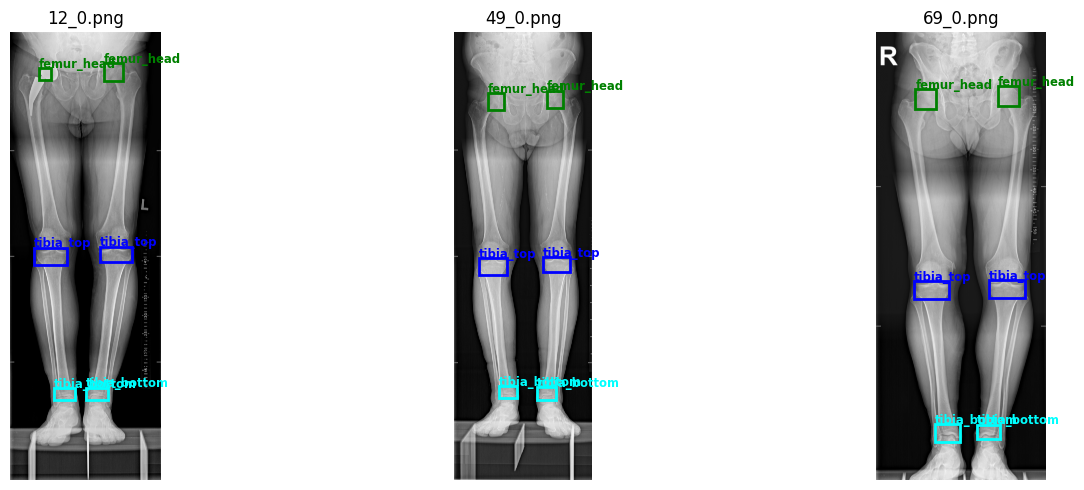

In [5]:
def show_random_samples(data_yaml, num_samples=3):
    with open(data_yaml, "r") as f:
        config = yaml.safe_load(f)
    
    with open(config["train"], "r") as f:
        images = f.read().splitlines()
        
    if not images:
        print("No images found to visualize.")
        return
        
    selected = random.sample(images, min(num_samples, len(images)))
    
    fig, axes = plt.subplots(1, len(selected), figsize=(15, 5))
    if len(selected) == 1:
        axes = [axes]
        
    for idx, img_path in enumerate(selected):
        ax = axes[idx]
        try:
            img = Image.open(img_path)
            ax.imshow(img, cmap="gray")
            w, h = img.size
            
            label_file = img_path.replace(os.path.join("images", ""), os.path.join("labels", "")).rsplit(".", 1)[0] + ".txt"
            if os.path.exists(label_file):
                with open(label_file, "r") as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            cls_id = int(parts[0])
                            x_center, y_center, box_w, box_h = map(float, parts[1:5])
                            xmin = (x_center - box_w / 2) * w
                            ymin = (y_center - box_h / 2) * h
                            rect_w = box_w * w
                            rect_h = box_h * h
                            
                            label = config["names"][cls_id] if cls_id < len(config["names"]) else str(cls_id)
                            c = ROI_COLORS.get(label, "red")
                            
                            rect = patches.Rectangle((xmin, ymin), rect_w, rect_h, 
                                                     linewidth=2, edgecolor=c, facecolor='none')
                            ax.add_patch(rect)
                            ax.text(xmin, ymin - 5, label, color=c, weight='bold', fontsize='small')
        except Exception as e:
            ax.set_title(f"Error loading {os.path.basename(img_path)}")
            continue
            
        ax.axis("off")
        ax.set_title(os.path.basename(img_path))
        
    plt.tight_layout()
    plt.show()

if os.path.exists(DATA_DIR):
    show_random_samples(data_yaml_path, num_samples=3)
else:
    print("Data directory not found; skipping sanity check visualization in dry run.")

## Core Utilities & Shared Components

To maintain a clean and reliable codebase, we implement shared utilities for image preprocessing, dataset management, and model training. This follows the DRY (Don't Repeat Yourself) principle, ensuring consistency across all keypoint detection stages.

In [6]:
def preprocess_roi(img, bbox, target_size=TARGET_SIZE):
    """
    Crops the Region of Interest (ROI) and applies letterbox resizing 
    to maintain original aspect ratio.
    """
    cropped = img.crop((bbox[0], bbox[1], bbox[0] + bbox[2], bbox[1] + bbox[3]))
    
    orig_w, orig_h = cropped.size
    scale = min(target_size / orig_w, target_size / orig_h)
    
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)
    
    resized = cropped.resize((new_w, new_h), Image.Resampling.LANCZOS)
    
    pad_left = (target_size - new_w) // 2
    pad_top = (target_size - new_h) // 2
    
    final_img = Image.new("RGB", (target_size, target_size), (0, 0, 0))
    final_img.paste(resized, (pad_left, pad_top))
    
    return final_img, scale, (pad_left, pad_top)

class RadiographKeypointDataset(Dataset):
    """
    Generic PyTorch Dataset for anatomical keypoint detection in radiographs.
    Explicitly filters images to only include those containing valid keypoint annotations
    and valid bounding boxes for the target category on the specified body side.
    """
    def __init__(self, coco_json_path, category_name, keypoint_names, split="train", split_ratios=(0.8, 0.1, 0.1), target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED, side=None):
        super().__init__()
        self.target_size = target_size
        self.heatmap_scale = heatmap_scale
        self.sigma = sigma
        self.keypoint_names = keypoint_names
        self.num_keypoints = len(keypoint_names)
        
        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)
            
        img_info_map = {img["id"]: img for img in coco_data["images"]}
        cat_id = next((cat["id"] for cat in coco_data["categories"] if cat["name"] == category_name), None)
        
        valid_anns = []
        for ann in coco_data["annotations"]:
            img_id = ann["image_id"]
            if img_id in img_info_map and ann["category_id"] == cat_id:
                kps = ann.get("keypoints", [])
                has_valid_kps = any(kps[i+2] > 0 and (kps[i] != 0 or kps[i+1] != 0) for i in range(0, len(kps), 3))
                bbox = ann.get("bbox", [])
                has_valid_box = len(bbox) == 4 and bbox[2] > 0 and bbox[3] > 0
                
                if has_valid_box:
                    img_w = img_info_map[img_id].get("width", 2860)
                    bbox_cx = bbox[0] + bbox[2] / 2.0
                    if side == "left" and bbox_cx >= img_w / 2.0:
                        continue
                    if side == "right" and bbox_cx < img_w / 2.0:
                        continue
                        
                if has_valid_kps and has_valid_box:
                    valid_anns.append(ann)
                    
        valid_img_ids = sorted(list({ann["image_id"] for ann in valid_anns}))
        
        random.seed(seed)
        random.shuffle(valid_img_ids)
        
        num_imgs = len(valid_img_ids)
        train_end = int(num_imgs * split_ratios[0])
        val_end = train_end + int(num_imgs * split_ratios[1])
        
        if split == "train":
            split_img_ids = set(valid_img_ids[:train_end])
        elif split == "val":
            split_img_ids = set(valid_img_ids[train_end:val_end])
        elif split == "test":
            split_img_ids = set(valid_img_ids[val_end:])
        else:
            split_img_ids = set(valid_img_ids)
            
        self.samples = []
        for ann in valid_anns:
            if ann["image_id"] in split_img_ids:
                filename = img_info_map[ann["image_id"]]["file_name"]
                self.samples.append({
                    "img_path": os.path.join(os.path.dirname(coco_json_path), filename),
                    "bbox": ann["bbox"],
                    "keypoints": ann["keypoints"]
                })
                        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        sample = self.samples[idx]
        bbox = sample["bbox"]
        
        img = Image.open(sample["img_path"]).convert("RGB")
        roi_img, scale, padding = preprocess_roi(img, bbox, self.target_size)
        
        final_kps = []
        for i in range(self.num_keypoints):
            kp_x = sample["keypoints"][i * 3]
            kp_y = sample["keypoints"][i * 3 + 1]
            rel_x, rel_y = kp_x - bbox[0], kp_y - bbox[1]
            final_x = rel_x * scale + padding[0]
            final_y = rel_y * scale + padding[1]
            final_kps.append([final_x, final_y])
        
        img_tensor = torch.from_numpy(np.array(roi_img)).permute(2, 0, 1).float() / 255.0
        
        hm_size = int(self.target_size * self.heatmap_scale)
        heatmap = np.zeros((self.num_keypoints, hm_size, hm_size), dtype=np.float32)
        x_grid = np.arange(0, hm_size, 1, np.float32)
        y_grid = np.arange(0, hm_size, 1, np.float32)[:, np.newaxis]
        
        for i in range(self.num_keypoints):
            kp_v = sample["keypoints"][i * 3 + 2]
            if kp_v > 0:
                kp_hm_x = final_kps[i][0] * self.heatmap_scale
                kp_hm_y = final_kps[i][1] * self.heatmap_scale
                heatmap[i] = np.exp(-((x_grid - kp_hm_x)**2 + (y_grid - kp_hm_y)**2) / (2 * self.sigma**2))
        
        return {
            "image": img_tensor,
            "heatmap": torch.from_numpy(heatmap),
            "keypoint": torch.tensor(final_kps, dtype=torch.float32),
            "img_path": sample["img_path"]
        }

def calculate_pck(preds, gts, threshold=0.05, normalize_by=TARGET_SIZE):
    dists = torch.norm(preds - gts, dim=-1)
    correct = dists < (threshold * normalize_by)
    return torch.mean(correct.float()).item()

def train_keypoint_model(model, train_loader, val_loader, optimizer, criterion, epochs, device, stage_name=""):
    train_losses, val_losses, val_nmses, val_pcks = [], [], [], []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for batch in train_loader:
            imgs, targets = batch["image"].to(device), batch["heatmap"].to(device)
            optimizer.zero_grad()
            pred_hms = model(imgs)
            loss = criterion(pred_hms, targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        train_loss = epoch_loss / len(train_loader)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss, epoch_preds, epoch_gts = 0.0, [], []
        with torch.no_grad():
            for batch in val_loader:
                imgs, targets, gts = batch["image"].to(device), batch["heatmap"].to(device), batch["keypoint"]
                pred_hms = model(imgs)
                val_loss += criterion(pred_hms, targets).item()
                coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
                epoch_preds.append(coords)
                epoch_gts.append(gts)
                
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        preds_cat = torch.cat(epoch_preds, dim=0)
        gts_cat = torch.cat(epoch_gts, dim=0)
        
        diff = preds_cat - gts_cat
        mse = torch.mean(torch.sum(diff ** 2, dim=-1))
        nmse = (mse / (TARGET_SIZE ** 2)).item()
        val_nmses.append(nmse)
        
        pck = calculate_pck(preds_cat, gts_cat, threshold=0.05)
        val_pcks.append(pck)
        
        print(f"Epoch {epoch+1}/{epochs} ({stage_name}) | Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | NMSE: {nmse:.6f} | PCK@0.05: {pck*100:.2f}%")
        
    return train_losses, val_losses, val_nmses, val_pcks

def visualize_keypoint_evaluation(sample_batch, stage_name, keypoint_names):
    sample_img, sample_hms, sample_gt, sample_pred = sample_batch
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    img_show = sample_img[0].permute(1, 2, 0).numpy()
    ax1.imshow(img_show, cmap="gray")
    
    for i, name in enumerate(keypoint_names):
        c = LANDMARK_COLORS.get(name, "red")
        ax1.plot(sample_gt[0, i, 0], sample_gt[0, i, 1], 'o', color=c, markersize=8, label=f"GT {name}")
        ax1.plot(sample_pred[0, i, 0], sample_pred[0, i, 1], 'x', color=c, markersize=8, label=f"Pred {name}")
        
    ax1.legend(fontsize='x-small', loc='upper right')
    ax1.set_title(f"{stage_name} Prediction Overlay")
    ax1.axis("off")
    
    hm_show = torch.max(sample_hms[0], dim=0)[0].numpy()
    im = ax2.imshow(hm_show, cmap='hot', interpolation='nearest')
    ax2.set_title(f"Predicted Heatmap ({stage_name})")
    ax2.axis("off")
    fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

## Part 2: Regions of Interests Detection

### Model Initialization & Training

We instantiate the YOLO architecture and conduct the optimization process over our processed anatomical dataset.

#### Load Model

We load the lightweight pretrained YOLO26 architecture to warm-start our feature extractors.

In [7]:
print("Loading YOLO26 pretrained weights...")
model = YOLO("yolo26n.pt")

Loading YOLO26 pretrained weights...


#### Training Loop

Execute the primary training routine using our configuration YAML and predefined hyperparameters. YOLO handles optimization, checkpointing, and metric validation internally.

In [8]:
print("Starting YOLO training loop...")
results = model.train(
    data=data_yaml_path,
    epochs=OD_EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH_SIZE,
    device=0,
    
    fliplr=0.5,    
    flipud=0.0,    
    degrees=5.0,   
    scale=0.1,     
    mosaic=1.0     
)
print("Training complete!")

Starting YOLO training loop...
New https://pypi.org/project/ultralytics/8.4.50 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.41 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tf/notebooks/yolo_data/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo2

#### Training Progress

Visualize the resulting optimization progression by plotting both training and validation loss alongside the mean Average Precision (mAP) scores over time.

In [9]:
results_path = os.path.join("runs", "detect", "train", "results.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    if "train/box_loss" in df.columns and "val/box_loss" in df.columns:
        ax1.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        ax1.plot(df["epoch"], df["val/box_loss"], label="Validation Box Loss")
        ax1.set_xlabel("Epochs")
        ax1.set_ylabel("Loss")
        ax1.set_title("Box Loss over Epochs")
        ax1.legend()
        ax1.grid(True)
        
    map_col = [col for col in df.columns if "mAP50" in col]
    if map_col:
        ax2.plot(df["epoch"], df[map_col[0]], label="mAP@50", color="green")
        ax2.set_xlabel("Epochs")
        ax2.set_ylabel("mAP Score")
        ax2.set_title("mAP over Epochs")
        ax2.legend()
        ax2.grid(True)
        
    plt.tight_layout()
    plt.show()
else:
    print("Results CSV not found; check YOLO output run path. (Expected during dry runs or before training completes)")

Results CSV not found; check YOLO output run path. (Expected during dry runs or before training completes)


### Evaluation & Inference

After training concludes, it is critical to evaluate our model's boundary box positioning and anatomical landmark identification on previously unseen test data.

#### Test Set Inference

Run validation metrics strictly over the held-out test split to ensure the model generalizes cleanly to new patient X-rays.

In [10]:
print("Running model validation on the test split...")
test_metrics = model.val(data=data_yaml_path, split="test")
print(f"Test Set mAP50: {test_metrics.box.map50:.4f}")
print(f"Test Set mAP50-95: {test_metrics.box.map:.4f}")

Running model validation on the test split...
Ultralytics 8.4.41 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 3.6±0.3 ms, read: 201.6±3.6 MB/s, size: 8515.3 KB)
val: Scanning /tf/notebooks/yolo_data/labels/test.cache... 7 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7/7 2.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.3s/it 3.3s
                   all          7         42      0.946      0.951      0.985      0.731
            femur_head          7         14       0.86      0.929      0.964      0.712
             tibia_top          7         14      0.979          1      0.995      0.774
          tibia_bottom          7         14          1      0.924      0.995      0.708
Speed: 0.9ms preprocess, 24.9ms inference, 0.0ms loss, 0.3ms postpro

#### Testing Metrics

Display standard PR curves, F1-score curves, and confusion matrix heatmaps generated during the testing stage.

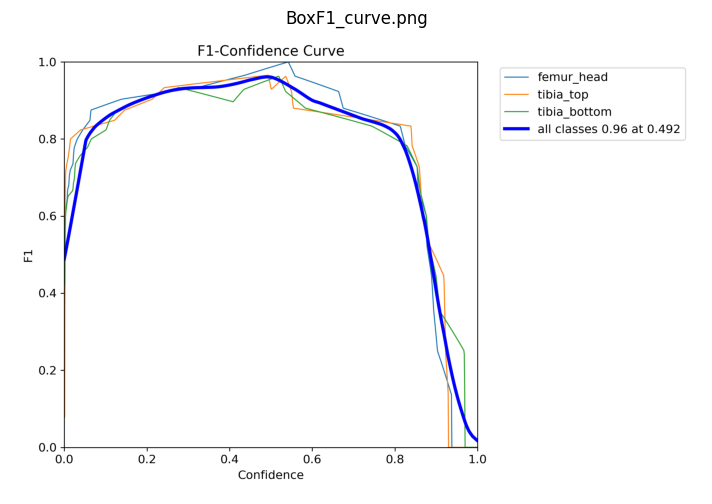

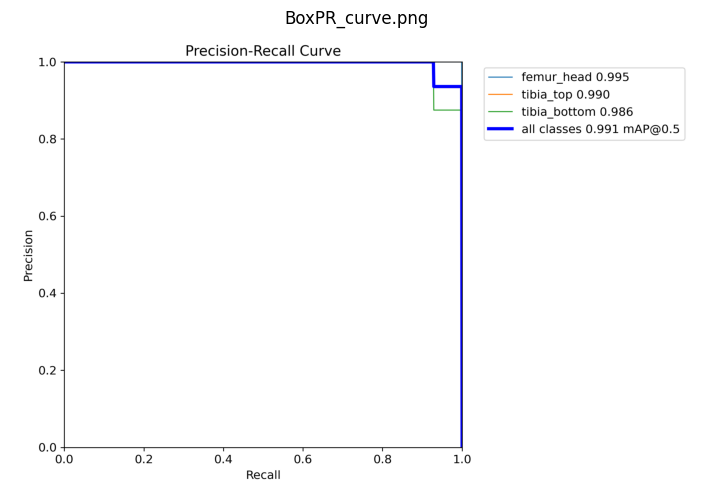

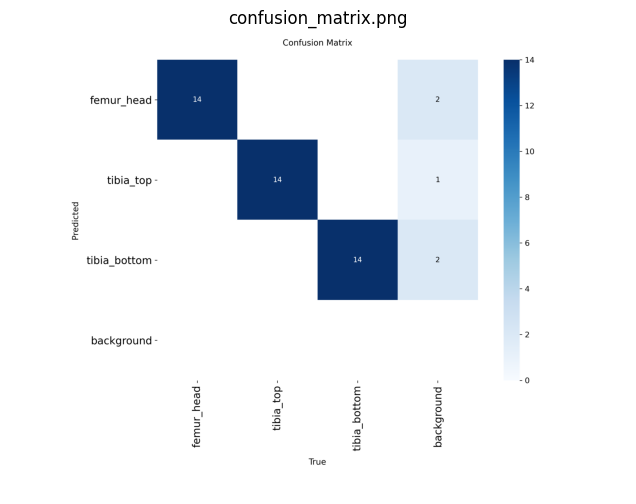

In [11]:
val_dir = os.path.join("runs", "detect", "val")
metric_plots = ["BoxF1_curve.png", "BoxPR_curve.png", "confusion_matrix.png"]

for plot_name in metric_plots:
    plot_path = os.path.join(val_dir, plot_name)
    if os.path.exists(plot_path):
        plt.figure(figsize=(10, 6))
        img = Image.open(plot_path)
        plt.imshow(img)
        plt.axis("off")
        plt.title(plot_name)
        plt.show()
    else:
        print(f"{plot_name} not found in {val_dir} (Available after evaluation)")

#### Result Inspection

Load and visualize raw prediction overlays alongside ground truth boxes on the test dataset so clinicians or engineers can spot correctable alignment errors or edge cases.

Running inference on test sample: /tf/notebooks/yolo_data/images/test/27_0.png

image 1/1 /tf/notebooks/yolo_data/images/test/27_0.png: 640x256 3 femur_heads, 2 tibia_tops, 2 tibia_bottoms, 80.7ms
Speed: 3.3ms preprocess, 80.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 256)


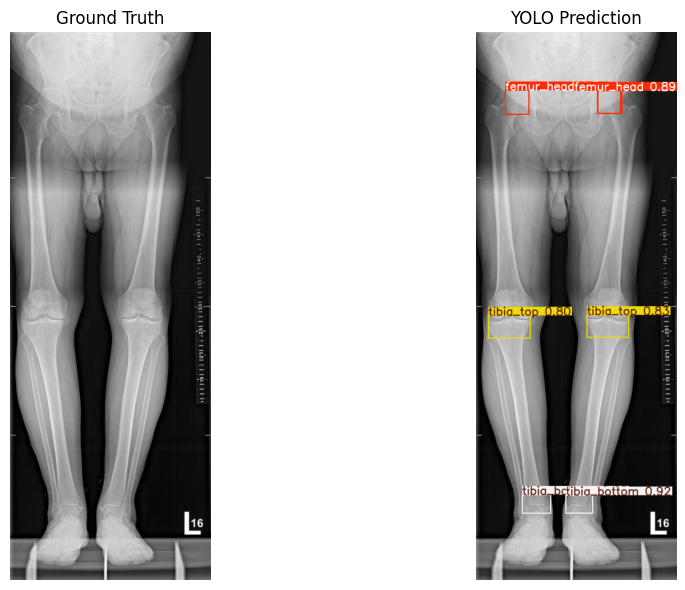

In [12]:
with open(os.path.join("yolo_data", "test.txt"), "r") as f:
    test_images = f.read().splitlines()

if test_images:
    sample_img = random.choice(test_images)
    print(f"Running inference on test sample: {sample_img}")
    
    pred = model(sample_img)
    
    fig, (ax_gt, ax_pred) = plt.subplots(1, 2, figsize=(12, 6))
    
    img_pil = Image.open(sample_img)
    ax_gt.imshow(img_pil, cmap="gray")
    ax_gt.set_title("Ground Truth")
    ax_gt.axis("off")
    
    res_plotted = pred[0].plot()
    ax_pred.imshow(res_plotted)
    ax_pred.set_title("YOLO Prediction")
    ax_pred.axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("No test images found.")

## Part 3L: Femur Head Keypoint Detection (Left Boundary Boxes)

In this stage, we crop the detected femur head region on the left side of the radiograph (patient's right leg) and train a Conformer-based keypoint detector to locate the femoral head center (`femur_head`).

### Dataset Implementation with Letterbox Resizing

We implement a custom PyTorch Dataset filtering for left boundary boxes to build consistent localized heatmaps.

In [13]:
fh_kp_names = ["femur_head"]

if os.path.exists(COCO_JSON_PATH):
    train_ds_fh_l = RadiographKeypointDataset(COCO_JSON_PATH, "femur_head", fh_kp_names, split="train", side="left")
    val_ds_fh_l = RadiographKeypointDataset(COCO_JSON_PATH, "femur_head", fh_kp_names, split="val", side="left")
    test_ds_fh_l = RadiographKeypointDataset(COCO_JSON_PATH, "femur_head", fh_kp_names, split="test", side="left")

    if len(train_ds_fh_l) > 0: train_loader_fh_l = DataLoader(train_ds_fh_l, batch_size=KP_BATCH_SIZE, shuffle=True)
    if len(val_ds_fh_l) > 0: val_loader_fh_l = DataLoader(val_ds_fh_l, batch_size=KP_BATCH_SIZE, shuffle=False)
    if len(test_ds_fh_l) > 0: test_loader_fh_l = DataLoader(test_ds_fh_l, batch_size=KP_BATCH_SIZE, shuffle=False)
    
    print(f"Femur Head Stage (Left side) Loaded! Samples: {len(train_ds_fh_l)} train, {len(val_ds_fh_l)} val, {len(test_ds_fh_l)} test")
else:
    print("Annotations not found; skipping Femur Head (Left) setup.")

Femur Head Stage (Left side) Loaded! Samples: 43 train, 5 val, 6 test


### Model Training & Optimization

Trains the network to minimize Mean Squared Error loss over the predicted spatial heatmaps for left boundary boxes.

Epoch 1/20 (Femur Head (Left)) | Loss: 0.132480 | Val Loss: 0.005867 | NMSE: 0.236158 | PCK@0.05: 0.00%
Epoch 2/20 (Femur Head (Left)) | Loss: 0.055766 | Val Loss: 0.004756 | NMSE: 0.139668 | PCK@0.05: 0.00%
Epoch 3/20 (Femur Head (Left)) | Loss: 0.022121 | Val Loss: 0.005260 | NMSE: 0.167504 | PCK@0.05: 0.00%
Epoch 4/20 (Femur Head (Left)) | Loss: 0.010462 | Val Loss: 0.005609 | NMSE: 0.126700 | PCK@0.05: 0.00%
Epoch 5/20 (Femur Head (Left)) | Loss: 0.007685 | Val Loss: 0.005640 | NMSE: 0.107895 | PCK@0.05: 0.00%
Epoch 6/20 (Femur Head (Left)) | Loss: 0.006748 | Val Loss: 0.005631 | NMSE: 0.163061 | PCK@0.05: 0.00%
Epoch 7/20 (Femur Head (Left)) | Loss: 0.005983 | Val Loss: 0.005339 | NMSE: 0.154499 | PCK@0.05: 0.00%
Epoch 8/20 (Femur Head (Left)) | Loss: 0.005396 | Val Loss: 0.005151 | NMSE: 0.117336 | PCK@0.05: 0.00%
Epoch 9/20 (Femur Head (Left)) | Loss: 0.005119 | Val Loss: 0.005028 | NMSE: 0.077692 | PCK@0.05: 20.00%
Epoch 10/20 (Femur Head (Left)) | Loss: 0.004954 | Val Loss: 0.

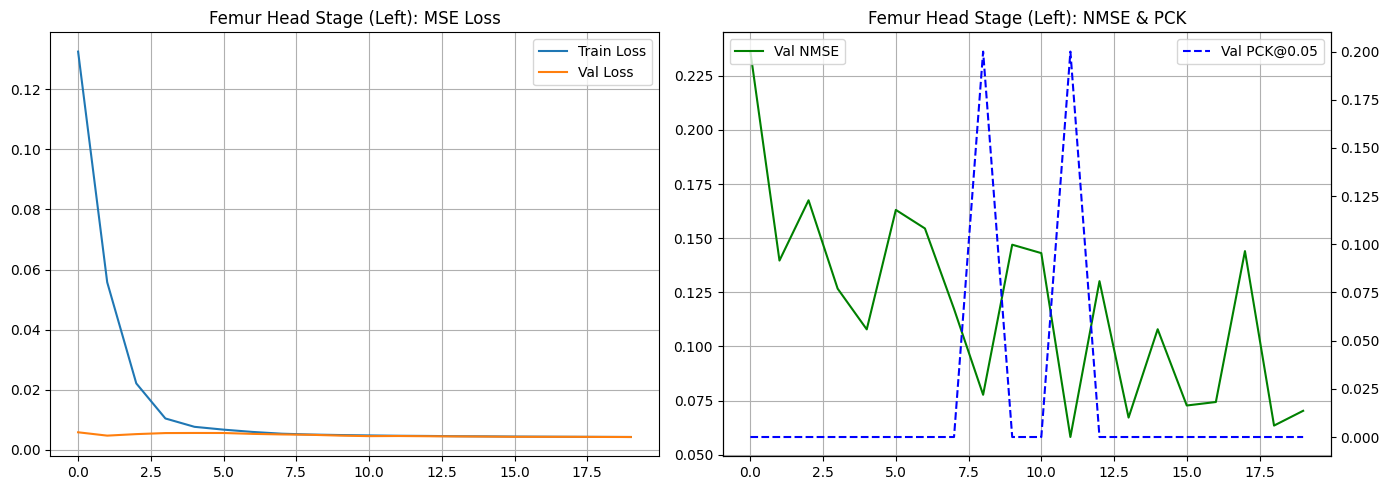

In [14]:
model_fh_l = Conformer_tiny_patch16_keypoint(num_keypoints=1).to(device)
optimizer_fh_l = optim.AdamW(model_fh_l.parameters(), lr=KP_LEARNING_RATE)

if 'train_loader_fh_l' in locals():
    train_losses, val_losses, val_nmses, val_pcks = train_keypoint_model(
        model_fh_l, train_loader_fh_l, val_loader_fh_l, 
        optimizer_fh_l, criterion, KP_EPOCHS, device, stage_name="Femur Head (Left)"
    )
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label="Train Loss"), ax1.plot(val_losses, label="Val Loss")
    ax1.set_title("Femur Head Stage (Left): MSE Loss"), ax1.legend(), ax1.grid(True)
    
    ax2.plot(val_nmses, label="Val NMSE", color="green")
    ax2_pck = ax2.twinx()
    ax2_pck.plot(val_pcks, label="Val PCK@0.05", color="blue", linestyle="--")
    ax2.set_title("Femur Head Stage (Left): NMSE & PCK"), ax2.legend(loc='upper left'), ax2.grid(True)
    ax2_pck.legend(loc='upper right')
    
    plt.tight_layout(), plt.show()
else:
    print("Skipping Femur Head (Left) training (Dataset missing).")

### Evaluation and Visualization

Extract coordinate pairs from output heatmaps, compute Normalized MSE, and visualize the ground truth against predictions for the left side.

Femur Head (Left) Test Set NMSE: 0.136471


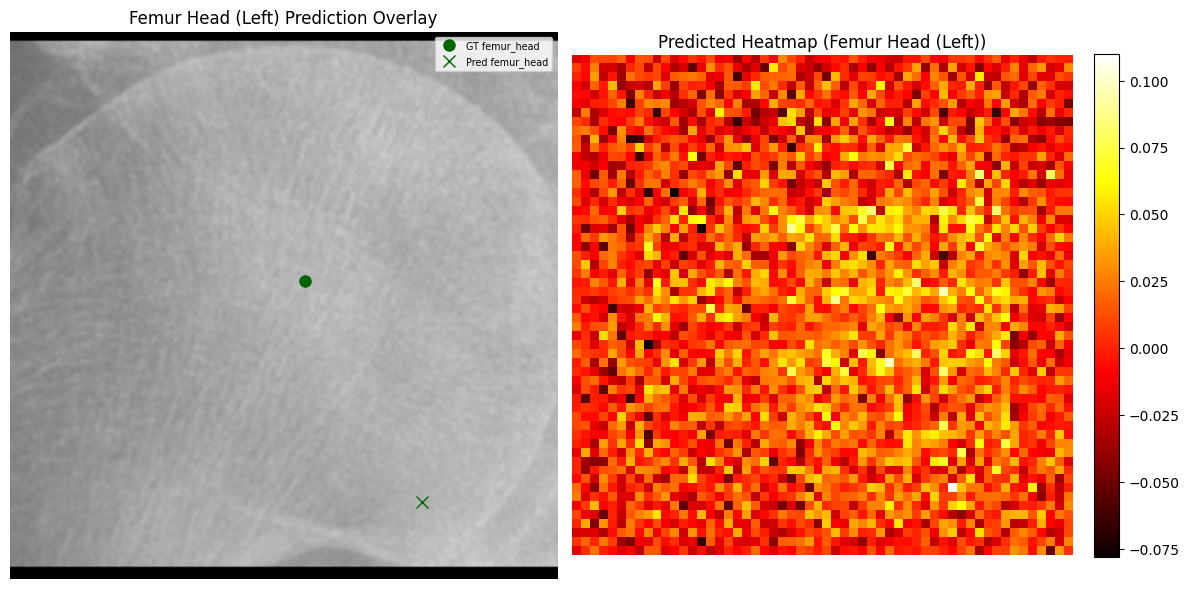

In [15]:
if 'test_loader_fh_l' in locals():
    model_fh_l.eval()
    all_preds, all_gts, sample_batch = [], [], None
    
    with torch.no_grad():
        for batch in test_loader_fh_l:
            imgs, kps = batch["image"].to(device), batch["keypoint"]
            pred_hms = model_fh_l(imgs)
            coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
            all_preds.append(coords), all_gts.append(kps)
            if sample_batch is None:
                sample_batch = (imgs.cpu(), pred_hms.cpu(), kps, coords)
                
    nmse_val = (torch.mean(torch.sum((torch.cat(all_preds) - torch.cat(all_gts))**2, dim=-1)) / (TARGET_SIZE**2)).item()
    print(f"Femur Head (Left) Test Set NMSE: {nmse_val:.6f}")
    
    visualize_keypoint_evaluation(sample_batch, "Femur Head (Left)", ["femur_head"])
else:
    print("Skipping Femur Head (Left) evaluation.")

## Part 3R: Femur Head Keypoint Detection (Right Boundary Boxes)

In this stage, we crop the detected femur head region on the right side of the radiograph (patient's left leg) and train a Conformer-based keypoint detector to locate the femoral head center (`femur_head`).

### Dataset Implementation with Letterbox Resizing

We implement a custom PyTorch Dataset filtering for right boundary boxes to build consistent localized heatmaps.

In [16]:
if os.path.exists(COCO_JSON_PATH):
    train_ds_fh_r = RadiographKeypointDataset(COCO_JSON_PATH, "femur_head", fh_kp_names, split="train", side="right")
    val_ds_fh_r = RadiographKeypointDataset(COCO_JSON_PATH, "femur_head", fh_kp_names, split="val", side="right")
    test_ds_fh_r = RadiographKeypointDataset(COCO_JSON_PATH, "femur_head", fh_kp_names, split="test", side="right")

    if len(train_ds_fh_r) > 0: train_loader_fh_r = DataLoader(train_ds_fh_r, batch_size=KP_BATCH_SIZE, shuffle=True)
    if len(val_ds_fh_r) > 0: val_loader_fh_r = DataLoader(val_ds_fh_r, batch_size=KP_BATCH_SIZE, shuffle=False)
    if len(test_ds_fh_r) > 0: test_loader_fh_r = DataLoader(test_ds_fh_r, batch_size=KP_BATCH_SIZE, shuffle=False)
    
    print(f"Femur Head Stage (Right side) Loaded! Samples: {len(train_ds_fh_r)} train, {len(val_ds_fh_r)} val, {len(test_ds_fh_r)} test")
else:
    print("Annotations not found; skipping Femur Head (Right) setup.")

Femur Head Stage (Right side) Loaded! Samples: 42 train, 5 val, 6 test


### Model Training & Optimization

Trains the network to minimize Mean Squared Error loss over the predicted spatial heatmaps for right boundary boxes.

Epoch 1/20 (Femur Head (Right)) | Loss: 0.148833 | Val Loss: 0.011867 | NMSE: 0.188243 | PCK@0.05: 0.00%
Epoch 2/20 (Femur Head (Right)) | Loss: 0.070696 | Val Loss: 0.006699 | NMSE: 0.138468 | PCK@0.05: 0.00%
Epoch 3/20 (Femur Head (Right)) | Loss: 0.026490 | Val Loss: 0.005716 | NMSE: 0.156613 | PCK@0.05: 0.00%
Epoch 4/20 (Femur Head (Right)) | Loss: 0.010163 | Val Loss: 0.005758 | NMSE: 0.087799 | PCK@0.05: 0.00%
Epoch 5/20 (Femur Head (Right)) | Loss: 0.006788 | Val Loss: 0.005840 | NMSE: 0.098105 | PCK@0.05: 0.00%
Epoch 6/20 (Femur Head (Right)) | Loss: 0.006309 | Val Loss: 0.005668 | NMSE: 0.110149 | PCK@0.05: 0.00%
Epoch 7/20 (Femur Head (Right)) | Loss: 0.005678 | Val Loss: 0.005310 | NMSE: 0.083819 | PCK@0.05: 0.00%
Epoch 8/20 (Femur Head (Right)) | Loss: 0.005078 | Val Loss: 0.005204 | NMSE: 0.092314 | PCK@0.05: 0.00%
Epoch 9/20 (Femur Head (Right)) | Loss: 0.004872 | Val Loss: 0.005035 | NMSE: 0.150860 | PCK@0.05: 0.00%
Epoch 10/20 (Femur Head (Right)) | Loss: 0.004803 | Val

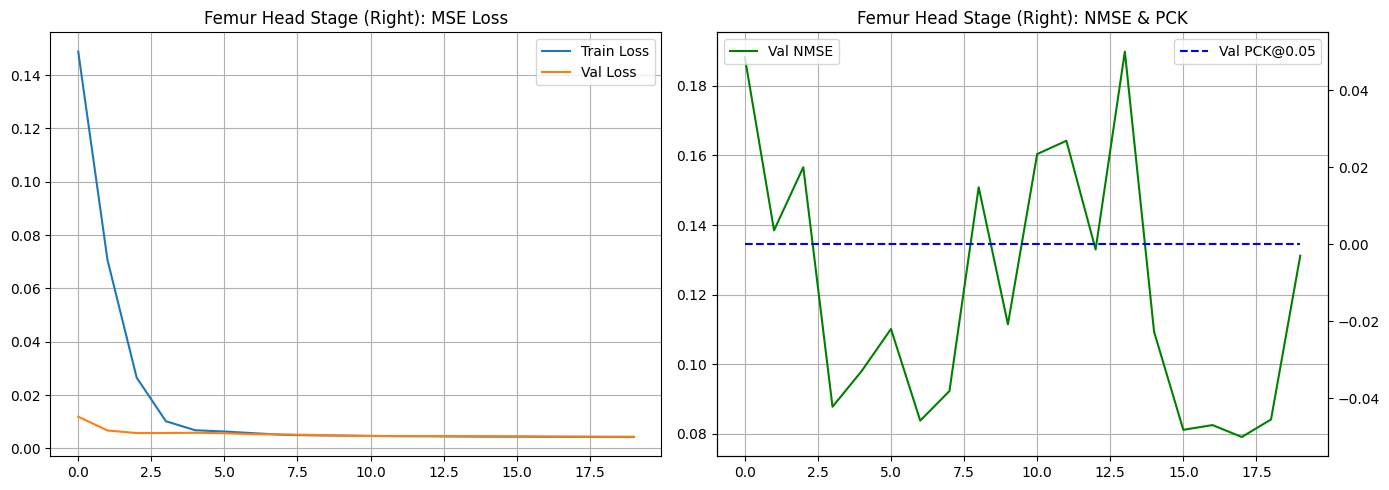

In [17]:
model_fh_r = Conformer_tiny_patch16_keypoint(num_keypoints=1).to(device)
optimizer_fh_r = optim.AdamW(model_fh_r.parameters(), lr=KP_LEARNING_RATE)

if 'train_loader_fh_r' in locals():
    train_losses, val_losses, val_nmses, val_pcks = train_keypoint_model(
        model_fh_r, train_loader_fh_r, val_loader_fh_r, 
        optimizer_fh_r, criterion, KP_EPOCHS, device, stage_name="Femur Head (Right)"
    )
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label="Train Loss"), ax1.plot(val_losses, label="Val Loss")
    ax1.set_title("Femur Head Stage (Right): MSE Loss"), ax1.legend(), ax1.grid(True)
    
    ax2.plot(val_nmses, label="Val NMSE", color="green")
    ax2_pck = ax2.twinx()
    ax2_pck.plot(val_pcks, label="Val PCK@0.05", color="blue", linestyle="--")
    ax2.set_title("Femur Head Stage (Right): NMSE & PCK"), ax2.legend(loc='upper left'), ax2.grid(True)
    ax2_pck.legend(loc='upper right')
    
    plt.tight_layout(), plt.show()
else:
    print("Skipping Femur Head (Right) training (Dataset missing).")

### Evaluation and Visualization

Extract coordinate pairs from output heatmaps, compute Normalized MSE, and visualize the ground truth against predictions for the right side.

Femur Head (Right) Test Set NMSE: 0.105802


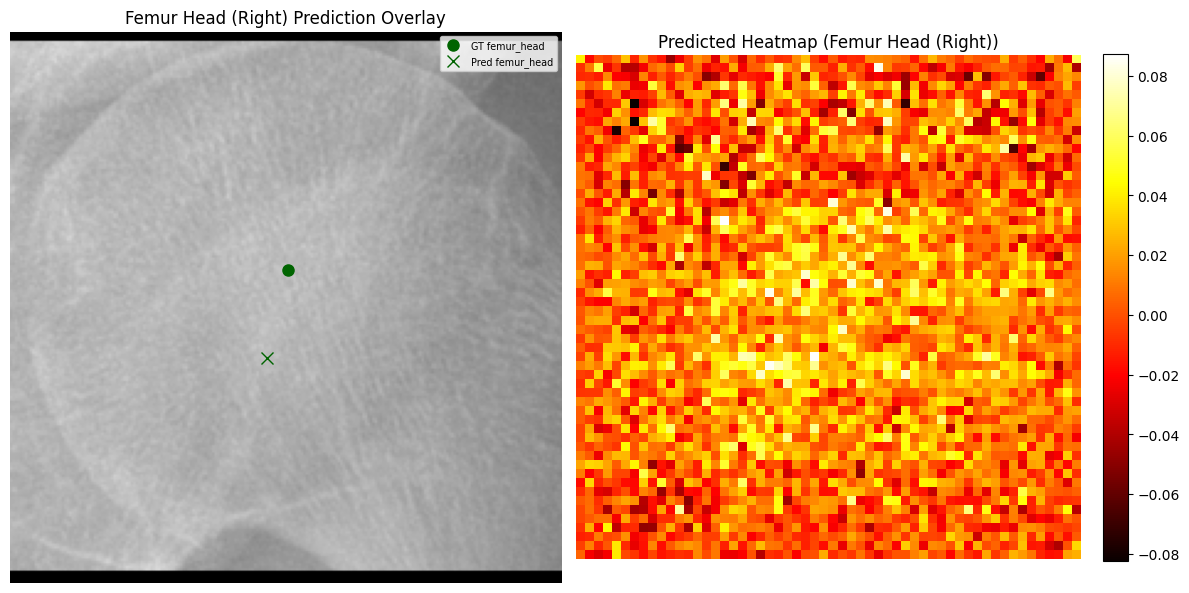

In [18]:
if 'test_loader_fh_r' in locals():
    model_fh_r.eval()
    all_preds, all_gts, sample_batch = [], [], None
    
    with torch.no_grad():
        for batch in test_loader_fh_r:
            imgs, kps = batch["image"].to(device), batch["keypoint"]
            pred_hms = model_fh_r(imgs)
            coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
            all_preds.append(coords), all_gts.append(kps)
            if sample_batch is None:
                sample_batch = (imgs.cpu(), pred_hms.cpu(), kps, coords)
                
    nmse_val = (torch.mean(torch.sum((torch.cat(all_preds) - torch.cat(all_gts))**2, dim=-1)) / (TARGET_SIZE**2)).item()
    print(f"Femur Head (Right) Test Set NMSE: {nmse_val:.6f}")
    
    visualize_keypoint_evaluation(sample_batch, "Femur Head (Right)", ["femur_head"])
else:
    print("Skipping Femur Head (Right) evaluation.")

## Part 4L: Tibia Top Keypoint Detection (Left Boundary Boxes)

In this stage, we crop the detected tibia top region on the left side of the radiograph (patient's right leg) and train a Conformer-based keypoint detector to locate the 3 keypoints (`knee_inner`, `ost_point`, `knee_outer`).

### Dataset Implementation with Letterbox Resizing

We implement a custom PyTorch Dataset filtering for left boundary boxes to build consistent localized heatmaps.

In [19]:
tt_kp_names = ["knee_inner", "ost_point", "knee_outer"]

if os.path.exists(COCO_JSON_PATH):
    train_ds_tt_l = RadiographKeypointDataset(COCO_JSON_PATH, "tibia_top", tt_kp_names, split="train", side="left")
    val_ds_tt_l = RadiographKeypointDataset(COCO_JSON_PATH, "tibia_top", tt_kp_names, split="val", side="left")
    test_ds_tt_l = RadiographKeypointDataset(COCO_JSON_PATH, "tibia_top", tt_kp_names, split="test", side="left")

    if len(train_ds_tt_l) > 0: train_loader_tt_l = DataLoader(train_ds_tt_l, batch_size=KP_BATCH_SIZE, shuffle=True)
    if len(val_ds_tt_l) > 0: val_loader_tt_l = DataLoader(val_ds_tt_l, batch_size=KP_BATCH_SIZE, shuffle=False)
    if len(test_ds_tt_l) > 0: test_loader_tt_l = DataLoader(test_ds_tt_l, batch_size=KP_BATCH_SIZE, shuffle=False)
    
    print(f"Tibia Top Stage (Left side) Loaded! Samples: {len(train_ds_tt_l)} train, {len(val_ds_tt_l)} val, {len(test_ds_tt_l)} test")
else:
    print("Annotations not found; skipping Tibia Top (Left) setup.")

Tibia Top Stage (Left side) Loaded! Samples: 43 train, 5 val, 6 test


### Model Training & Optimization

Trains the network to minimize Mean Squared Error loss over the predicted spatial heatmaps for left boundary boxes.

Epoch 1/20 (Tibia Top (Left)) | Loss: 0.074105 | Val Loss: 0.006080 | NMSE: 0.323196 | PCK@0.05: 0.00%
Epoch 2/20 (Tibia Top (Left)) | Loss: 0.027268 | Val Loss: 0.005795 | NMSE: 0.299292 | PCK@0.05: 0.00%
Epoch 3/20 (Tibia Top (Left)) | Loss: 0.011785 | Val Loss: 0.005440 | NMSE: 0.278532 | PCK@0.05: 0.00%
Epoch 4/20 (Tibia Top (Left)) | Loss: 0.006848 | Val Loss: 0.004935 | NMSE: 0.399224 | PCK@0.05: 0.00%
Epoch 5/20 (Tibia Top (Left)) | Loss: 0.005219 | Val Loss: 0.004511 | NMSE: 0.331325 | PCK@0.05: 0.00%
Epoch 6/20 (Tibia Top (Left)) | Loss: 0.004533 | Val Loss: 0.004141 | NMSE: 0.430022 | PCK@0.05: 6.67%
Epoch 7/20 (Tibia Top (Left)) | Loss: 0.004152 | Val Loss: 0.003913 | NMSE: 0.257909 | PCK@0.05: 13.33%
Epoch 8/20 (Tibia Top (Left)) | Loss: 0.003865 | Val Loss: 0.003740 | NMSE: 0.158636 | PCK@0.05: 6.67%
Epoch 9/20 (Tibia Top (Left)) | Loss: 0.003691 | Val Loss: 0.003610 | NMSE: 0.107750 | PCK@0.05: 26.67%
Epoch 10/20 (Tibia Top (Left)) | Loss: 0.003582 | Val Loss: 0.003513 | 

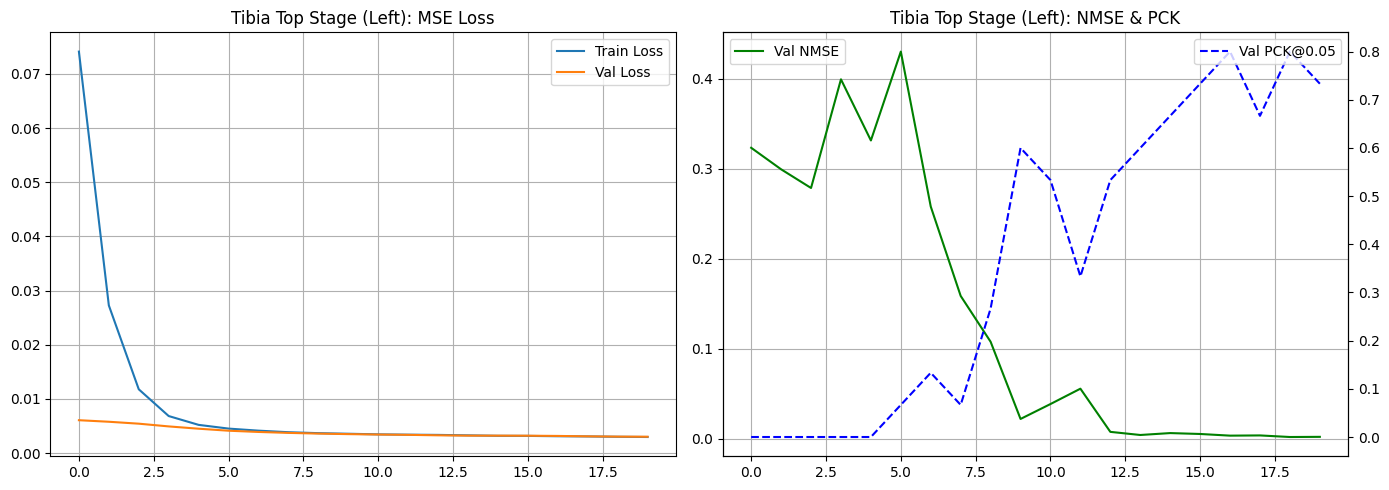

In [20]:
model_tt_l = Conformer_tiny_patch16_keypoint(num_keypoints=3).to(device)
optimizer_tt_l = optim.AdamW(model_tt_l.parameters(), lr=KP_LEARNING_RATE)

if 'train_loader_tt_l' in locals():
    train_losses, val_losses, val_nmses, val_pcks = train_keypoint_model(
        model_tt_l, train_loader_tt_l, val_loader_tt_l, 
        optimizer_tt_l, criterion, KP_EPOCHS, device, stage_name="Tibia Top (Left)"
    )
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label="Train Loss"), ax1.plot(val_losses, label="Val Loss")
    ax1.set_title("Tibia Top Stage (Left): MSE Loss"), ax1.legend(), ax1.grid(True)
    
    ax2.plot(val_nmses, label="Val NMSE", color="green")
    ax2_pck = ax2.twinx()
    ax2_pck.plot(val_pcks, label="Val PCK@0.05", color="blue", linestyle="--")
    ax2.set_title("Tibia Top Stage (Left): NMSE & PCK"), ax2.legend(loc='upper left'), ax2.grid(True)
    ax2_pck.legend(loc='upper right')
    
    plt.tight_layout(), plt.show()
else:
    print("Skipping Tibia Top (Left) training (Dataset missing).")

### Evaluation and Visualization

Extract coordinate pairs from output heatmaps, compute Normalized MSE, and visualize the ground truth against predictions for the left side.

Tibia Top (Left) Test Set NMSE: 0.022082


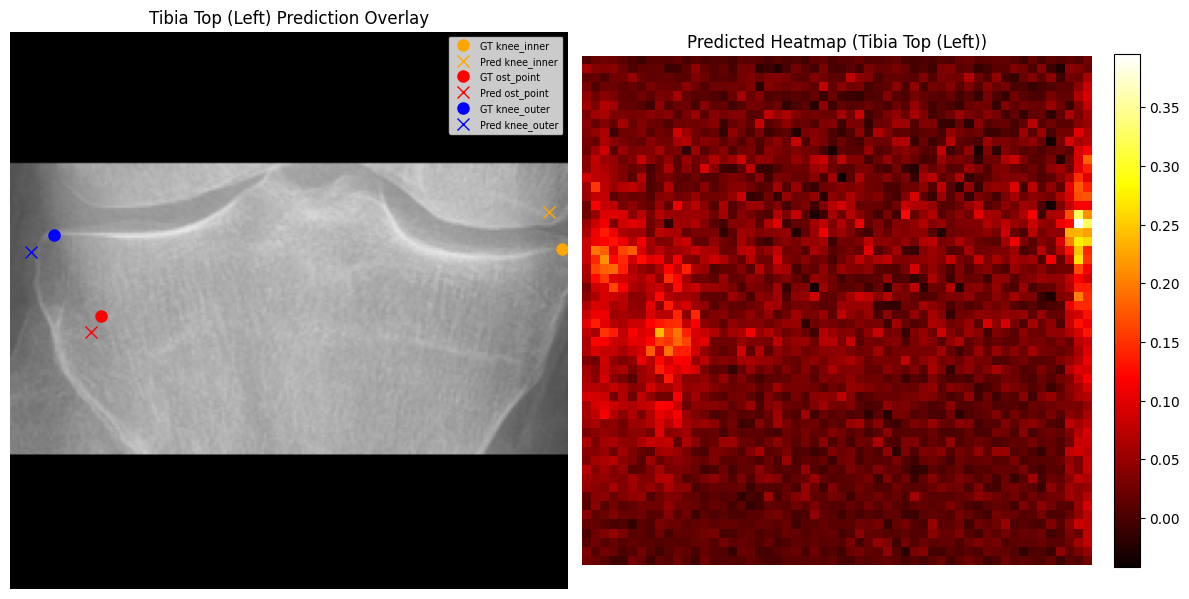

In [21]:
if 'test_loader_tt_l' in locals():
    model_tt_l.eval()
    all_preds, all_gts, sample_batch = [], [], None
    
    with torch.no_grad():
        for batch in test_loader_tt_l:
            imgs, kps = batch["image"].to(device), batch["keypoint"]
            pred_hms = model_tt_l(imgs)
            coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
            all_preds.append(coords), all_gts.append(kps)
            if sample_batch is None:
                sample_batch = (imgs.cpu(), pred_hms.cpu(), kps, coords)
                
    nmse_val = (torch.mean(torch.sum((torch.cat(all_preds) - torch.cat(all_gts))**2, dim=-1)) / (TARGET_SIZE**2)).item()
    print(f"Tibia Top (Left) Test Set NMSE: {nmse_val:.6f}")
    
    visualize_keypoint_evaluation(sample_batch, "Tibia Top (Left)", ["knee_inner", "ost_point", "knee_outer"])
else:
    print("Skipping Tibia Top (Left) evaluation.")

## Part 4R: Tibia Top Keypoint Detection (Right Boundary Boxes)

In this stage, we crop the detected tibia top region on the right side of the radiograph (patient's left leg) and train a Conformer-based keypoint detector to locate the 3 keypoints (`knee_inner`, `ost_point`, `knee_outer`).

### Dataset Implementation with Letterbox Resizing

We implement a custom PyTorch Dataset filtering for right boundary boxes to build consistent localized heatmaps.

In [22]:
if os.path.exists(COCO_JSON_PATH):
    train_ds_tt_r = RadiographKeypointDataset(COCO_JSON_PATH, "tibia_top", tt_kp_names, split="train", side="right")
    val_ds_tt_r = RadiographKeypointDataset(COCO_JSON_PATH, "tibia_top", tt_kp_names, split="val", side="right")
    test_ds_tt_r = RadiographKeypointDataset(COCO_JSON_PATH, "tibia_top", tt_kp_names, split="test", side="right")

    if len(train_ds_tt_r) > 0: train_loader_tt_r = DataLoader(train_ds_tt_r, batch_size=KP_BATCH_SIZE, shuffle=True)
    if len(val_ds_tt_r) > 0: val_loader_tt_r = DataLoader(val_ds_tt_r, batch_size=KP_BATCH_SIZE, shuffle=False)
    if len(test_ds_tt_r) > 0: test_loader_tt_r = DataLoader(test_ds_tt_r, batch_size=KP_BATCH_SIZE, shuffle=False)
    
    print(f"Tibia Top Stage (Right side) Loaded! Samples: {len(train_ds_tt_r)} train, {len(val_ds_tt_r)} val, {len(test_ds_tt_r)} test")
else:
    print("Annotations not found; skipping Tibia Top (Right) setup.")

Tibia Top Stage (Right side) Loaded! Samples: 43 train, 5 val, 6 test


### Model Training & Optimization

Trains the network to minimize Mean Squared Error loss over the predicted spatial heatmaps for right boundary boxes.

Epoch 1/20 (Tibia Top (Right)) | Loss: 0.155732 | Val Loss: 0.014640 | NMSE: 0.182776 | PCK@0.05: 0.00%
Epoch 2/20 (Tibia Top (Right)) | Loss: 0.083764 | Val Loss: 0.015666 | NMSE: 0.315919 | PCK@0.05: 0.00%
Epoch 3/20 (Tibia Top (Right)) | Loss: 0.043568 | Val Loss: 0.017535 | NMSE: 0.340837 | PCK@0.05: 0.00%
Epoch 4/20 (Tibia Top (Right)) | Loss: 0.023210 | Val Loss: 0.017027 | NMSE: 0.196084 | PCK@0.05: 0.00%
Epoch 5/20 (Tibia Top (Right)) | Loss: 0.013240 | Val Loss: 0.013783 | NMSE: 0.143501 | PCK@0.05: 0.00%
Epoch 6/20 (Tibia Top (Right)) | Loss: 0.008425 | Val Loss: 0.009954 | NMSE: 0.207294 | PCK@0.05: 0.00%
Epoch 7/20 (Tibia Top (Right)) | Loss: 0.006004 | Val Loss: 0.007285 | NMSE: 0.203849 | PCK@0.05: 6.67%
Epoch 8/20 (Tibia Top (Right)) | Loss: 0.004740 | Val Loss: 0.005407 | NMSE: 0.154318 | PCK@0.05: 13.33%
Epoch 9/20 (Tibia Top (Right)) | Loss: 0.004149 | Val Loss: 0.004376 | NMSE: 0.078403 | PCK@0.05: 20.00%
Epoch 10/20 (Tibia Top (Right)) | Loss: 0.003856 | Val Loss: 0

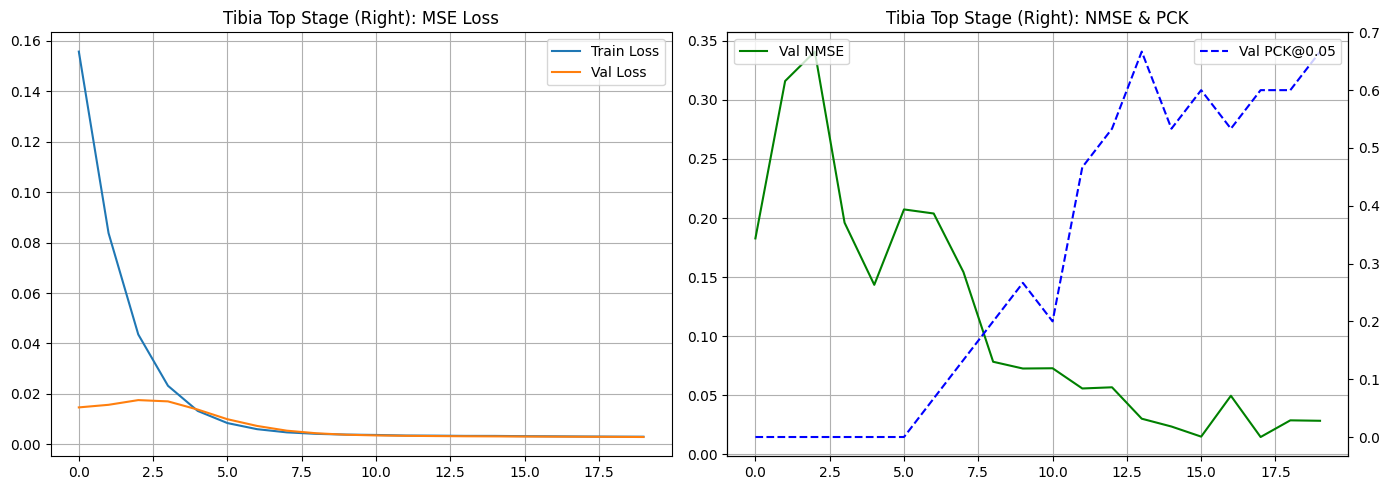

In [23]:
model_tt_r = Conformer_tiny_patch16_keypoint(num_keypoints=3).to(device)
optimizer_tt_r = optim.AdamW(model_tt_r.parameters(), lr=KP_LEARNING_RATE)

if 'train_loader_tt_r' in locals():
    train_losses, val_losses, val_nmses, val_pcks = train_keypoint_model(
        model_tt_r, train_loader_tt_r, val_loader_tt_r, 
        optimizer_tt_r, criterion, KP_EPOCHS, device, stage_name="Tibia Top (Right)"
    )
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label="Train Loss"), ax1.plot(val_losses, label="Val Loss")
    ax1.set_title("Tibia Top Stage (Right): MSE Loss"), ax1.legend(), ax1.grid(True)
    
    ax2.plot(val_nmses, label="Val NMSE", color="green")
    ax2_pck = ax2.twinx()
    ax2_pck.plot(val_pcks, label="Val PCK@0.05", color="blue", linestyle="--")
    ax2.set_title("Tibia Top Stage (Right): NMSE & PCK"), ax2.legend(loc='upper left'), ax2.grid(True)
    ax2_pck.legend(loc='upper right')
    
    plt.tight_layout(), plt.show()
else:
    print("Skipping Tibia Top (Right) training (Dataset missing).")

### Evaluation and Visualization

Extract coordinate pairs from output heatmaps, compute Normalized MSE, and visualize the ground truth against predictions for the right side.

Tibia Top (Right) Test Set NMSE: 0.011564


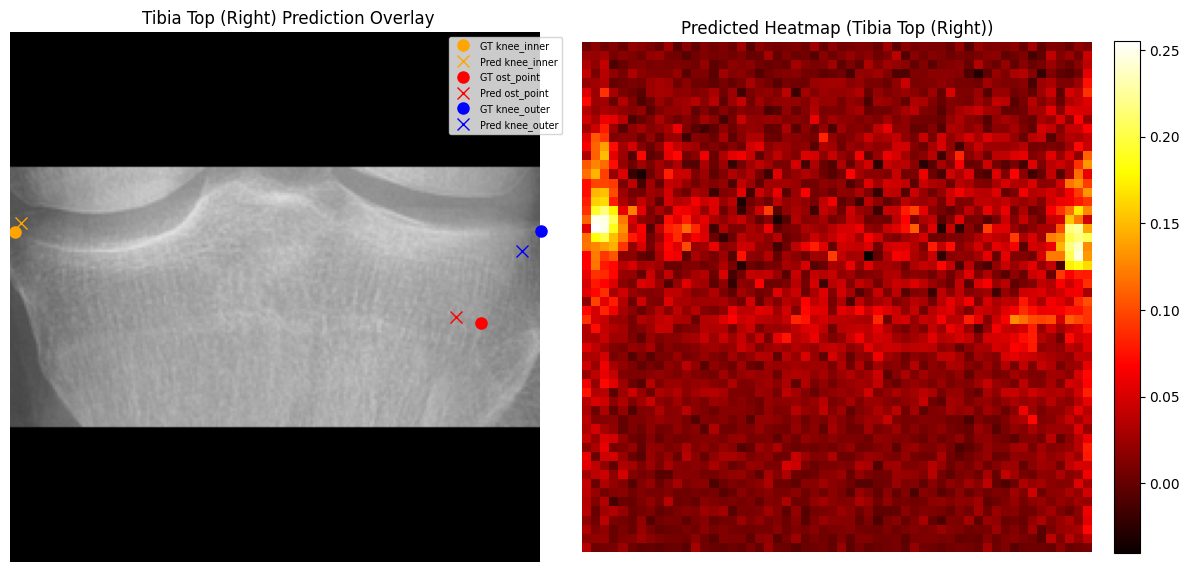

In [24]:
if 'test_loader_tt_r' in locals():
    model_tt_r.eval()
    all_preds, all_gts, sample_batch = [], [], None
    
    with torch.no_grad():
        for batch in test_loader_tt_r:
            imgs, kps = batch["image"].to(device), batch["keypoint"]
            pred_hms = model_tt_r(imgs)
            coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
            all_preds.append(coords), all_gts.append(kps)
            if sample_batch is None:
                sample_batch = (imgs.cpu(), pred_hms.cpu(), kps, coords)
                
    nmse_val = (torch.mean(torch.sum((torch.cat(all_preds) - torch.cat(all_gts))**2, dim=-1)) / (TARGET_SIZE**2)).item()
    print(f"Tibia Top (Right) Test Set NMSE: {nmse_val:.6f}")
    
    visualize_keypoint_evaluation(sample_batch, "Tibia Top (Right)", ["knee_inner", "ost_point", "knee_outer"])
else:
    print("Skipping Tibia Top (Right) evaluation.")

## Part 5L: Tibia Bottom Keypoint Detection (Left Boundary Boxes)

In this stage, we crop the detected tibia bottom region on the left side of the radiograph (patient's right leg) and train a Conformer-based keypoint detector to locate the 2 keypoints (`ankle_inner`, `ankle_outer`).

### Dataset Implementation with Letterbox Resizing

We implement a custom PyTorch Dataset filtering for left boundary boxes to build consistent localized heatmaps.

In [25]:
tb_kp_names = ["ankle_inner", "ankle_outer"]

if os.path.exists(COCO_JSON_PATH):
    train_ds_tb_l = RadiographKeypointDataset(COCO_JSON_PATH, "tibia_bottom", tb_kp_names, split="train", side="left")
    val_ds_tb_l = RadiographKeypointDataset(COCO_JSON_PATH, "tibia_bottom", tb_kp_names, split="val", side="left")
    test_ds_tb_l = RadiographKeypointDataset(COCO_JSON_PATH, "tibia_bottom", tb_kp_names, split="test", side="left")

    if len(train_ds_tb_l) > 0: train_loader_tb_l = DataLoader(train_ds_tb_l, batch_size=KP_BATCH_SIZE, shuffle=True)
    if len(val_ds_tb_l) > 0: val_loader_tb_l = DataLoader(val_ds_tb_l, batch_size=KP_BATCH_SIZE, shuffle=False)
    if len(test_ds_tb_l) > 0: test_loader_tb_l = DataLoader(test_ds_tb_l, batch_size=KP_BATCH_SIZE, shuffle=False)
    
    print(f"Tibia Bottom Stage (Left side) Loaded! Samples: {len(train_ds_tb_l)} train, {len(val_ds_tb_l)} val, {len(test_ds_tb_l)} test")
else:
    print("Annotations not found; skipping Tibia Bottom (Left) setup.")

Tibia Bottom Stage (Left side) Loaded! Samples: 41 train, 5 val, 6 test


### Model Training & Optimization

Trains the network to minimize Mean Squared Error loss over the predicted spatial heatmaps for left boundary boxes.

Epoch 1/20 (Tibia Bottom (Left)) | Loss: 0.137424 | Val Loss: 0.008320 | NMSE: 0.337270 | PCK@0.05: 0.00%
Epoch 2/20 (Tibia Bottom (Left)) | Loss: 0.065807 | Val Loss: 0.008882 | NMSE: 0.198009 | PCK@0.05: 0.00%
Epoch 3/20 (Tibia Bottom (Left)) | Loss: 0.029753 | Val Loss: 0.009622 | NMSE: 0.150852 | PCK@0.05: 0.00%
Epoch 4/20 (Tibia Bottom (Left)) | Loss: 0.013932 | Val Loss: 0.009440 | NMSE: 0.368962 | PCK@0.05: 0.00%
Epoch 5/20 (Tibia Bottom (Left)) | Loss: 0.007631 | Val Loss: 0.008078 | NMSE: 0.332383 | PCK@0.05: 0.00%
Epoch 6/20 (Tibia Bottom (Left)) | Loss: 0.005527 | Val Loss: 0.006316 | NMSE: 0.278755 | PCK@0.05: 0.00%
Epoch 7/20 (Tibia Bottom (Left)) | Loss: 0.005039 | Val Loss: 0.005302 | NMSE: 0.193469 | PCK@0.05: 0.00%
Epoch 8/20 (Tibia Bottom (Left)) | Loss: 0.004865 | Val Loss: 0.004767 | NMSE: 0.173807 | PCK@0.05: 0.00%
Epoch 9/20 (Tibia Bottom (Left)) | Loss: 0.004690 | Val Loss: 0.004610 | NMSE: 0.238349 | PCK@0.05: 0.00%
Epoch 10/20 (Tibia Bottom (Left)) | Loss: 0.00

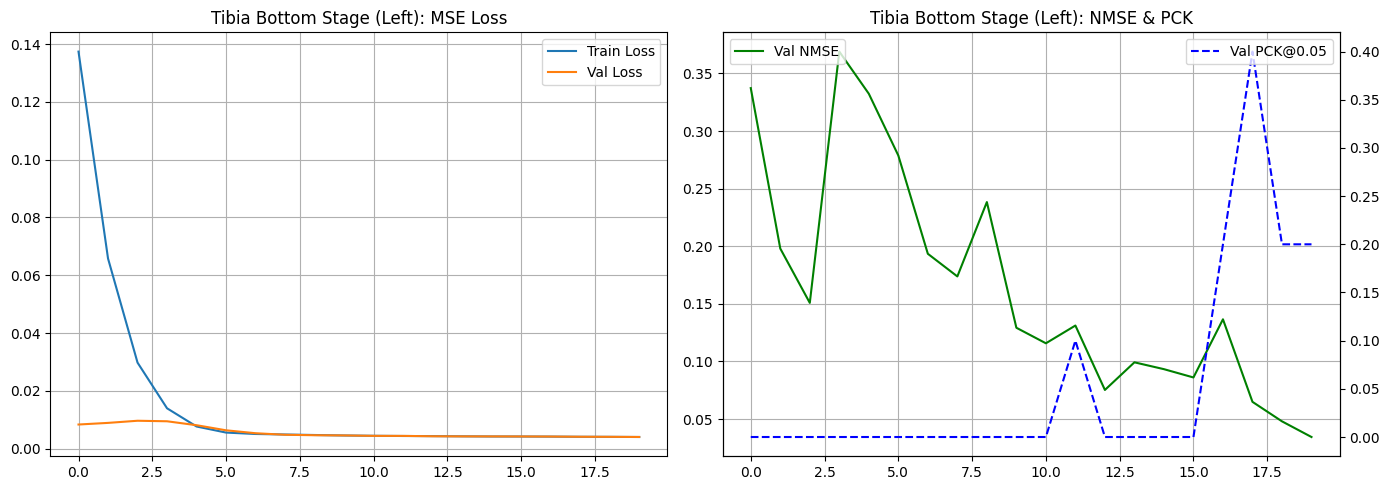

In [26]:
model_tb_l = Conformer_tiny_patch16_keypoint(num_keypoints=2).to(device)
optimizer_tb_l = optim.AdamW(model_tb_l.parameters(), lr=KP_LEARNING_RATE)

if 'train_loader_tb_l' in locals():
    train_losses, val_losses, val_nmses, val_pcks = train_keypoint_model(
        model_tb_l, train_loader_tb_l, val_loader_tb_l, 
        optimizer_tb_l, criterion, KP_EPOCHS, device, stage_name="Tibia Bottom (Left)"
    )
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label="Train Loss"), ax1.plot(val_losses, label="Val Loss")
    ax1.set_title("Tibia Bottom Stage (Left): MSE Loss"), ax1.legend(), ax1.grid(True)
    
    ax2.plot(val_nmses, label="Val NMSE", color="green")
    ax2_pck = ax2.twinx()
    ax2_pck.plot(val_pcks, label="Val PCK@0.05", color="blue", linestyle="--")
    ax2.set_title("Tibia Bottom Stage (Left): NMSE & PCK"), ax2.legend(loc='upper left'), ax2.grid(True)
    ax2_pck.legend(loc='upper right')
    
    plt.tight_layout(), plt.show()
else:
    print("Skipping Tibia Bottom (Left) training (Dataset missing).")

### Evaluation and Visualization

Extract coordinate pairs from output heatmaps, compute Normalized MSE, and visualize the ground truth against predictions for the left side.

Tibia Bottom (Left) Test Set NMSE: 0.067099


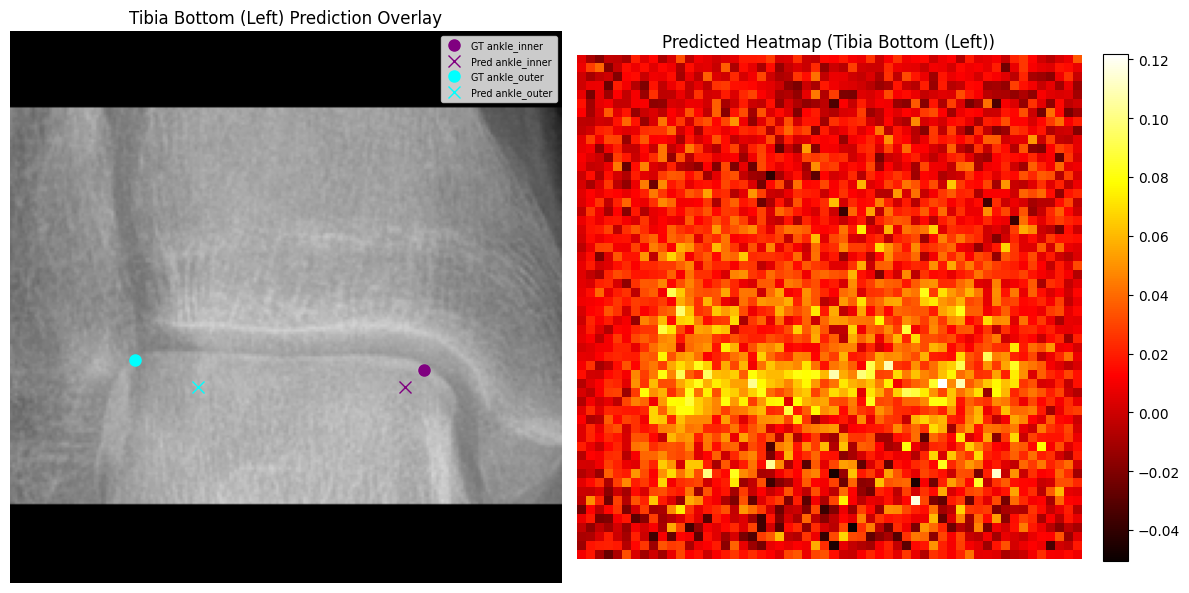

In [27]:
if 'test_loader_tb_l' in locals():
    model_tb_l.eval()
    all_preds, all_gts, sample_batch = [], [], None
    
    with torch.no_grad():
        for batch in test_loader_tb_l:
            imgs, kps = batch["image"].to(device), batch["keypoint"]
            pred_hms = model_tb_l(imgs)
            coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
            all_preds.append(coords), all_gts.append(kps)
            if sample_batch is None:
                sample_batch = (imgs.cpu(), pred_hms.cpu(), kps, coords)
                
    nmse_val = (torch.mean(torch.sum((torch.cat(all_preds) - torch.cat(all_gts))**2, dim=-1)) / (TARGET_SIZE**2)).item()
    print(f"Tibia Bottom (Left) Test Set NMSE: {nmse_val:.6f}")
    
    visualize_keypoint_evaluation(sample_batch, "Tibia Bottom (Left)", ["ankle_inner", "ankle_outer"])
else:
    print("Skipping Tibia Bottom (Left) evaluation.")

## Part 5R: Tibia Bottom Keypoint Detection (Right Boundary Boxes)

In this stage, we crop the detected tibia bottom region on the right side of the radiograph (patient's left leg) and train a Conformer-based keypoint detector to locate the 2 keypoints (`ankle_inner`, `ankle_outer`).

### Dataset Implementation with Letterbox Resizing

We implement a custom PyTorch Dataset filtering for right boundary boxes to build consistent localized heatmaps.

In [28]:
if os.path.exists(COCO_JSON_PATH):
    train_ds_tb_r = RadiographKeypointDataset(COCO_JSON_PATH, "tibia_bottom", tb_kp_names, split="train", side="right")
    val_ds_tb_r = RadiographKeypointDataset(COCO_JSON_PATH, "tibia_bottom", tb_kp_names, split="val", side="right")
    test_ds_tb_r = RadiographKeypointDataset(COCO_JSON_PATH, "tibia_bottom", tb_kp_names, split="test", side="right")

    if len(train_ds_tb_r) > 0: train_loader_tb_r = DataLoader(train_ds_tb_r, batch_size=KP_BATCH_SIZE, shuffle=True)
    if len(val_ds_tb_r) > 0: val_loader_tb_r = DataLoader(val_ds_tb_r, batch_size=KP_BATCH_SIZE, shuffle=False)
    if len(test_ds_tb_r) > 0: test_loader_tb_r = DataLoader(test_ds_tb_r, batch_size=KP_BATCH_SIZE, shuffle=False)
    
    print(f"Tibia Bottom Stage (Right side) Loaded! Samples: {len(train_ds_tb_r)} train, {len(val_ds_tb_r)} val, {len(test_ds_tb_r)} test")
else:
    print("Annotations not found; skipping Tibia Bottom (Right) setup.")

Tibia Bottom Stage (Right side) Loaded! Samples: 44 train, 5 val, 7 test


### Model Training & Optimization

Trains the network to minimize Mean Squared Error loss over the predicted spatial heatmaps for right boundary boxes.

Epoch 1/20 (Tibia Bottom (Right)) | Loss: 0.122172 | Val Loss: 0.015742 | NMSE: 0.341898 | PCK@0.05: 0.00%
Epoch 2/20 (Tibia Bottom (Right)) | Loss: 0.056068 | Val Loss: 0.017196 | NMSE: 0.323410 | PCK@0.05: 0.00%
Epoch 3/20 (Tibia Bottom (Right)) | Loss: 0.024886 | Val Loss: 0.013837 | NMSE: 0.194105 | PCK@0.05: 0.00%
Epoch 4/20 (Tibia Bottom (Right)) | Loss: 0.011842 | Val Loss: 0.009781 | NMSE: 0.220371 | PCK@0.05: 0.00%
Epoch 5/20 (Tibia Bottom (Right)) | Loss: 0.007182 | Val Loss: 0.007725 | NMSE: 0.176851 | PCK@0.05: 0.00%
Epoch 6/20 (Tibia Bottom (Right)) | Loss: 0.005840 | Val Loss: 0.006446 | NMSE: 0.218165 | PCK@0.05: 0.00%
Epoch 7/20 (Tibia Bottom (Right)) | Loss: 0.005450 | Val Loss: 0.005619 | NMSE: 0.256954 | PCK@0.05: 0.00%
Epoch 8/20 (Tibia Bottom (Right)) | Loss: 0.005152 | Val Loss: 0.005280 | NMSE: 0.205055 | PCK@0.05: 0.00%
Epoch 9/20 (Tibia Bottom (Right)) | Loss: 0.004858 | Val Loss: 0.004946 | NMSE: 0.254629 | PCK@0.05: 0.00%
Epoch 10/20 (Tibia Bottom (Right)) | 

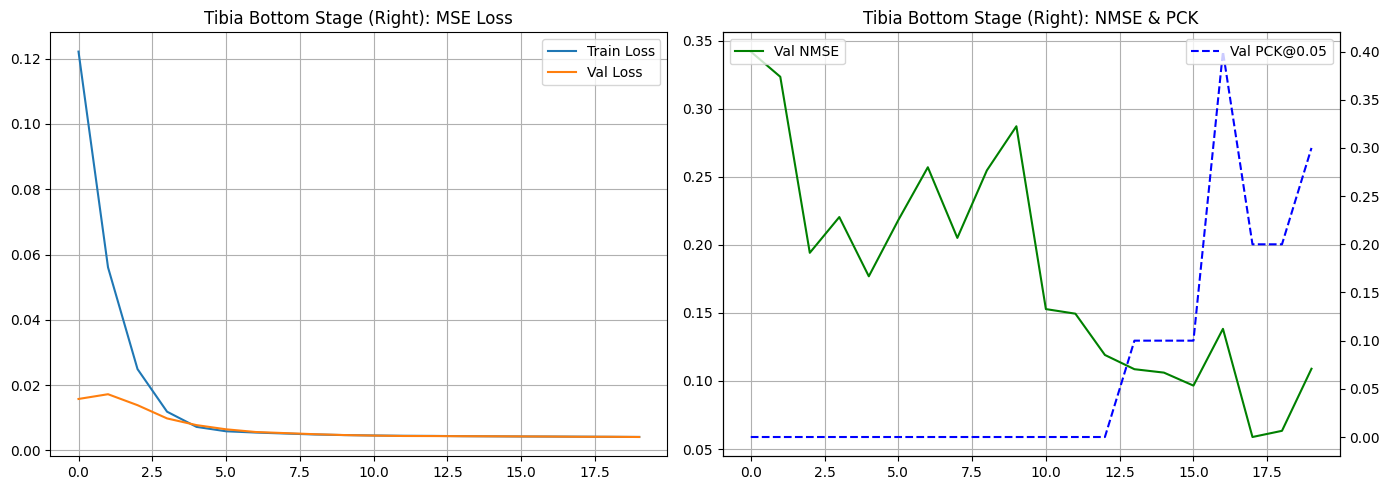

In [29]:
model_tb_r = Conformer_tiny_patch16_keypoint(num_keypoints=2).to(device)
optimizer_tb_r = optim.AdamW(model_tb_r.parameters(), lr=KP_LEARNING_RATE)

if 'train_loader_tb_r' in locals():
    train_losses, val_losses, val_nmses, val_pcks = train_keypoint_model(
        model_tb_r, train_loader_tb_r, val_loader_tb_r, 
        optimizer_tb_r, criterion, KP_EPOCHS, device, stage_name="Tibia Bottom (Right)"
    )
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label="Train Loss"), ax1.plot(val_losses, label="Val Loss")
    ax1.set_title("Tibia Bottom Stage (Right): MSE Loss"), ax1.legend(), ax1.grid(True)
    
    ax2.plot(val_nmses, label="Val NMSE", color="green")
    ax2_pck = ax2.twinx()
    ax2_pck.plot(val_pcks, label="Val PCK@0.05", color="blue", linestyle="--")
    ax2.set_title("Tibia Bottom Stage (Right): NMSE & PCK"), ax2.legend(loc='upper left'), ax2.grid(True)
    ax2_pck.legend(loc='upper right')
    
    plt.tight_layout(), plt.show()
else:
    print("Skipping Tibia Bottom (Right) training (Dataset missing).")

### Evaluation and Visualization

Extract coordinate pairs from output heatmaps, compute Normalized MSE, and visualize the ground truth against predictions for the right side.

Tibia Bottom (Right) Test Set NMSE: 0.154501


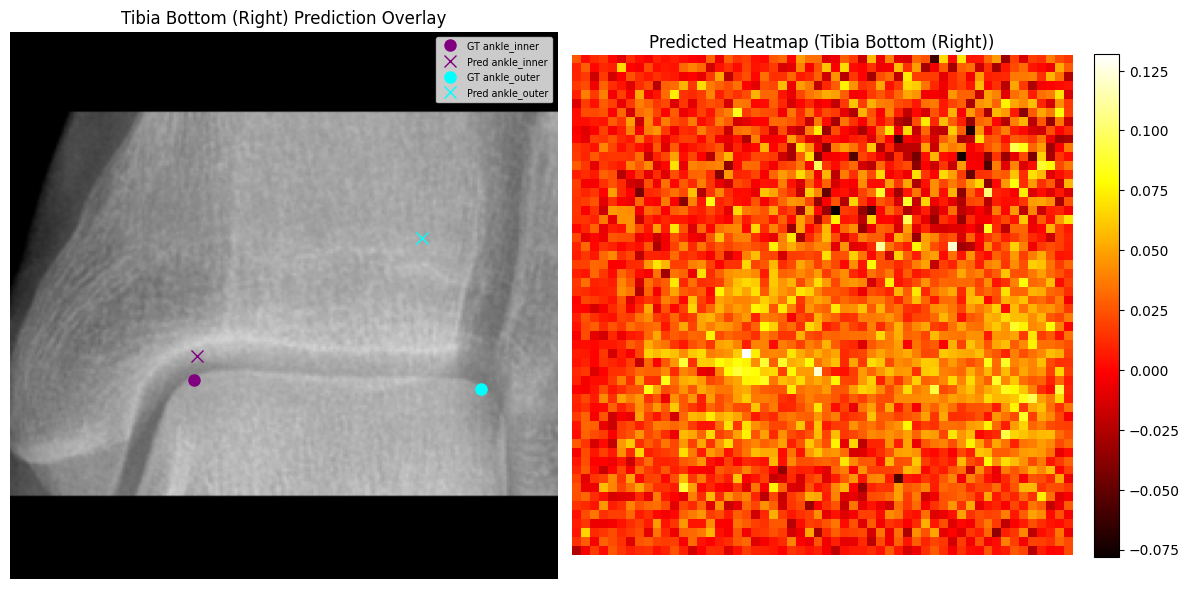

In [30]:
if 'test_loader_tb_r' in locals():
    model_tb_r.eval()
    all_preds, all_gts, sample_batch = [], [], None
    
    with torch.no_grad():
        for batch in test_loader_tb_r:
            imgs, kps = batch["image"].to(device), batch["keypoint"]
            pred_hms = model_tb_r(imgs)
            coords = extract_coordinates(pred_hms.cpu(), scale_factor=4.0)
            all_preds.append(coords), all_gts.append(kps)
            if sample_batch is None:
                sample_batch = (imgs.cpu(), pred_hms.cpu(), kps, coords)
                
    nmse_val = (torch.mean(torch.sum((torch.cat(all_preds) - torch.cat(all_gts))**2, dim=-1)) / (TARGET_SIZE**2)).item()
    print(f"Tibia Bottom (Right) Test Set NMSE: {nmse_val:.6f}")
    
    visualize_keypoint_evaluation(sample_batch, "Tibia Bottom (Right)", ["ankle_inner", "ankle_outer"])
else:
    print("Skipping Tibia Bottom (Right) evaluation.")

## Part 6: Pipeline Evaluation

In this final stage, we integrate the YOLO region detector and the Conformer keypoint detectors into a unified pipeline. For each image in our test set, we calculate the surgical correction angle for a High Tibial Osteotomy (HTO) and evaluate the model's accuracy against ground truth annotations.

### Geometry & Mapping Utilities

We define functions to map detected keypoints from localized crops back to the original full-scale radiograph coordinates, as well as geometric functions to compute the Fujisawa point and correction angles using standard vector atan2 formulas.

In [31]:
def map_to_orig(kp_final, bbox, target_size=TARGET_SIZE):
    """Maps keypoints from the localized letterboxed crop back to original image coordinates."""
    x_min, y_min, w_orig, h_orig = bbox
    
    scale = min(target_size / w_orig, target_size / h_orig)
    pad_left = (target_size - int(w_orig * scale)) // 2
    pad_top = (target_size - int(h_orig * scale)) // 2
    
    kp_rel_x = (kp_final[0] - pad_left) / scale
    kp_rel_y = (kp_final[1] - pad_top) / scale
    
    return np.array([kp_rel_x + x_min, kp_rel_y + y_min])

def calculate_intersection(p1, p2, target_y):
    """Finds the intersection of the line (p1, p2) with the horizontal line y = target_y."""
    if p2[0] == p1[0]: 
        return p1[0]
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    if m == 0: return p1[0] 
    return (target_y - p1[1]) / m + p1[0]

def get_hto_angle(points):
    """
    Computes Fujisawa point and true correction angle Alpha using the Miniaci method for HTO.
    points dict: {femur_head, knee_inner, ost_point, knee_outer, ankle_inner, ankle_outer}
    """
    # Distal ankle center midpoint
    ankle_c = (points["ankle_inner"] + points["ankle_outer"]) / 2.0
    ankle_y = ankle_c[1]
    
    # 1. Find Fujisawa point at 62.5% of plateau width from medial to lateral
    fujisawa = points["knee_inner"] + 0.625 * (points["knee_outer"] - points["knee_inner"])
    
    # 2. Intersect Target Mechanical Axis (femur_head -> fujisawa) with ankle level line
    target_intersect_x = calculate_intersection(points["femur_head"], fujisawa, ankle_y)
    target_at_ankle = np.array([target_intersect_x, ankle_y])
    
    # 3. Miniaci Deformity Correction Arc: Rotation angle at Hinge (ost_point) pivoting ankle_c to target_at_ankle
    v_orig_ankle = ankle_c - points["ost_point"]
    theta_orig = math.atan2(v_orig_ankle[1], v_orig_ankle[0])
    
    v_target_ankle = target_at_ankle - points["ost_point"]
    theta_target = math.atan2(v_target_ankle[1], v_target_ankle[0])
    
    # Correction angle Alpha
    alpha = abs(theta_orig - theta_target) * 180.0 / math.pi
    return alpha, fujisawa, ankle_c, target_at_ankle

### End-to-End Inference Pipeline

We iterate through the test images, route detected ROIs to separate Left and Right hemisphere models, evaluate keypoint completeness independently per body side, and compute Miniaci correction angles for both sides.

Starting pipeline evaluation on 7 images...
[1] 23_0.png: Success. Right (GT: 18.65°, Pred: 7.78°).
[2] 27_0.png: Success. Left (GT: 13.39°, Pred: 13.60°). Right (GT: 11.26°, Pred: 12.94°).
[3] 38_0.png: Success. Left (GT: 8.24°, Pred: 8.35°). Right (GT: 5.72°, Pred: 4.31°).
[4] 41_0.png: Success. Left (GT: 0.72°, Pred: 0.30°). Right (GT: 2.52°, Pred: 5.44°).
[5] 45_0.png: Success. Left (GT: 10.68°, Pred: 11.64°). Right (GT: 4.49°, Pred: 0.28°).
[6] 13_0.png: Success. Left (GT: 1.53°, Pred: 0.70°). Right (GT: 3.08°, Pred: 2.59°).
[7] 24_0.png: Success. Left (GT: 6.33°, Pred: 8.14°). Right (GT: 5.11°, Pred: 5.70°).

PIPELINE PERFORMANCE SUMMARY (ALL HEMISPHERES)
Total Side Evaluations: 13
Mean Squared Error:     11.9290
Mean Absolute Error:    2.0401°
Max Absolute Error:     10.8762°
Error Std Dev:          3.3678°


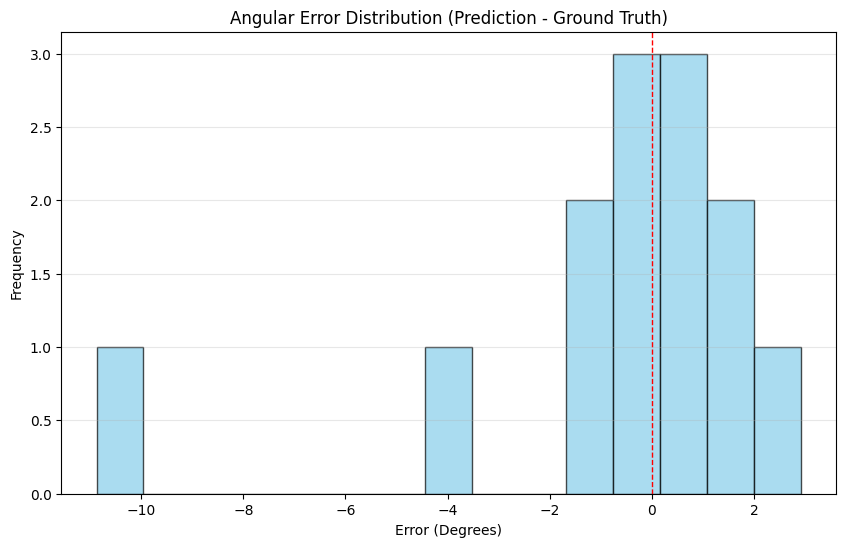

In [32]:
with open(COCO_JSON_PATH, "r") as f:
    coco_eval_data = json.load(f)

img_info_eval = {img["file_name"]: img for img in coco_eval_data["images"]}
ann_by_img_eval = {}
for ann in coco_eval_data["annotations"]:
    img_id = ann["image_id"]
    if img_id not in ann_by_img_eval:
        ann_by_img_eval[img_id] = []
    ann_by_img_eval[img_id].append(ann)

def run_test_pipeline(test_img_paths):
    pipeline_results = []
    
    model.eval()
    
    fh_l = globals().get('model_fh_l')
    fh_r = globals().get('model_fh_r')
    tt_l = globals().get('model_tt_l')
    tt_r = globals().get('model_tt_r')
    tb_l = globals().get('model_tb_l')
    tb_r = globals().get('model_tb_r')
    
    if fh_l: fh_l.eval()
    if fh_r: fh_r.eval()
    if tt_l: tt_l.eval()
    if tt_r: tt_r.eval()
    if tb_l: tb_l.eval()
    if tb_r: tb_r.eval()
    
    required = ["femur_head", "knee_inner", "ost_point", "knee_outer", "ankle_inner", "ankle_outer"]
    print(f"Starting pipeline evaluation on {len(test_img_paths)} images...")
    
    for img_idx, img_path in enumerate(test_img_paths):
        filename = os.path.basename(img_path)
        if filename not in img_info_eval:
            print(f"[{img_idx+1}] {filename}: Not found in metadata. Skipping.")
            continue
            
        img_w = img_info_eval[filename].get("width", 2860)
        img_orig = Image.open(img_path).convert("RGB")
        
        yolo_res = model(img_path, verbose=False)[0]
        boxes = yolo_res.boxes.xyxy.cpu().numpy()
        classes = yolo_res.boxes.cls.cpu().numpy()
        
        pred_pts_l = {}
        pred_pts_r = {}
        
        for i in range(len(classes)):
            cls_name = CLASSES[int(classes[i])]
            box = boxes[i] if i < len(boxes) else [0, 0, 100, 100]
            bbox_wh = [box[0], box[1], box[2]-box[0], box[3]-box[1]]
            
            bbox_cx = box[0] + (box[2] - box[0]) / 2.0
            is_left_side = bbox_cx < img_w / 2.0
            
            roi_img, scale, padding = preprocess_roi(img_orig, bbox_wh, TARGET_SIZE)
            roi_tensor = torch.from_numpy(np.array(roi_img)).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0
            
            target_dict = pred_pts_l if is_left_side else pred_pts_r
            
            with torch.no_grad():
                if cls_name == "femur_head":
                    target_model = fh_l if is_left_side else fh_r
                    if target_model:
                        pred_hm = target_model(roi_tensor)
                        coords = extract_coordinates(pred_hm.cpu(), scale_factor=4.0).squeeze().numpy()
                        target_dict["femur_head"] = map_to_orig(coords, bbox_wh)
                    
                elif cls_name == "tibia_top":
                    target_model = tt_l if is_left_side else tt_r
                    if target_model:
                        pred_hm = target_model(roi_tensor)
                        coords = extract_coordinates(pred_hm.cpu(), scale_factor=4.0).squeeze().numpy()
                        if coords.ndim == 1: coords = np.expand_dims(coords, 0)
                        for k_idx, k_name in enumerate(["knee_inner", "ost_point", "knee_outer"]):
                            if k_idx < len(coords): target_dict[k_name] = map_to_orig(coords[k_idx], bbox_wh)
                            
                elif cls_name == "tibia_bottom":
                    target_model = tb_l if is_left_side else tb_r
                    if target_model:
                        pred_hm = target_model(roi_tensor)
                        coords = extract_coordinates(pred_hm.cpu(), scale_factor=4.0).squeeze().numpy()
                        if coords.ndim == 1: coords = np.expand_dims(coords, 0)
                        for k_idx, k_name in enumerate(["ankle_inner", "ankle_outer"]):
                            if k_idx < len(coords): target_dict[k_name] = map_to_orig(coords[k_idx], bbox_wh)
        
        gt_pts_l = {}
        gt_pts_r = {}
        img_id = img_info_eval[filename]["id"]
        annotations = ann_by_img_eval.get(img_id, [])
        
        for ann in annotations:
            cat_name = CLASSES[ann["category_id"]-1]
            if not ann.get("keypoints"): continue
            
            kps = ann["keypoints"]
            ann_bbox = ann.get("bbox", [0, 0, 0, 0])
            ann_cx = ann_bbox[0] + ann_bbox[2] / 2.0
            target_dict = gt_pts_l if ann_cx < img_w / 2.0 else gt_pts_r
            
            if cat_name == "femur_head" and len(kps) >= 2:
                target_dict["femur_head"] = np.array([kps[0], kps[1]])
            elif cat_name == "tibia_top" and len(kps) >= 8:
                for k_idx, k_name in enumerate(["knee_inner", "ost_point", "knee_outer"]):
                    target_dict[k_name] = np.array([kps[k_idx*3], kps[k_idx*3+1]])
            elif cat_name == "tibia_bottom" and len(kps) >= 5:
                for k_idx, k_name in enumerate(["ankle_inner", "ankle_outer"]):
                    target_dict[k_name] = np.array([kps[k_idx*3], kps[k_idx*3+1]])
        
        res_l = None
        res_r = None
        
        if all(k in pred_pts_l for k in required) and all(k in gt_pts_l for k in required):
            pred_alpha, p_fuji, p_ank, p_targ = get_hto_angle(pred_pts_l)
            pred_pts_l["fujisawa"] = p_fuji
            pred_pts_l["ankle_c"] = p_ank
            pred_pts_l["target_at_ankle"] = p_targ
            
            gt_alpha, gt_fuji, gt_ank, gt_targ = get_hto_angle(gt_pts_l)
            gt_pts_l["fujisawa"] = gt_fuji
            gt_pts_l["ankle_c"] = gt_ank
            gt_pts_l["target_at_ankle"] = gt_targ
            
            res_l = {
                "side": "Left Side",
                "pred_angle": pred_alpha,
                "gt_angle": gt_alpha,
                "pred_pts": pred_pts_l,
                "gt_pts": gt_pts_l
            }
            
        if all(k in pred_pts_r for k in required) and all(k in gt_pts_r for k in required):
            pred_alpha, p_fuji, p_ank, p_targ = get_hto_angle(pred_pts_r)
            pred_pts_r["fujisawa"] = p_fuji
            pred_pts_r["ankle_c"] = p_ank
            pred_pts_r["target_at_ankle"] = p_targ
            
            gt_alpha, gt_fuji, gt_ank, gt_targ = get_hto_angle(gt_pts_r)
            gt_pts_r["fujisawa"] = gt_fuji
            gt_pts_r["ankle_c"] = gt_ank
            gt_pts_r["target_at_ankle"] = gt_targ
            
            res_r = {
                "side": "Right Side",
                "pred_angle": pred_alpha,
                "gt_angle": gt_alpha,
                "pred_pts": pred_pts_r,
                "gt_pts": gt_pts_r
            }
            
        if res_l or res_r:
            p_entry = {
                "filename": filename,
                "img_path": img_path,
                "res_l": res_l,
                "res_r": res_r
            }
            pipeline_results.append(p_entry)
            msg = f"[{img_idx+1}] {filename}: Success."
            if res_l: msg += f" Left (GT: {res_l['gt_angle']:.2f}°, Pred: {res_l['pred_angle']:.2f}°)."
            if res_r: msg += f" Right (GT: {res_r['gt_angle']:.2f}°, Pred: {res_r['pred_angle']:.2f}°)."
            print(msg)
        else:
            print(f"[{img_idx+1}] {filename}: Incomplete keypoints for independent hemisphere evaluation.")
            
    return pipeline_results

if os.path.exists(os.path.join(OUTPUT_DIR, "test.txt")):
    with open(os.path.join(OUTPUT_DIR, "test.txt"), "r") as f:
        test_img_filenames = f.read().splitlines()
    eval_results = run_test_pipeline(test_img_filenames[:50])
    
    all_errors = []
    for r in eval_results:
        if r["res_l"]:
            all_errors.append(r["res_l"]["pred_angle"] - r["res_l"]["gt_angle"])
        if r["res_r"]:
            all_errors.append(r["res_r"]["pred_angle"] - r["res_r"]["gt_angle"])
            
    if all_errors:
        abs_errors = [abs(e) for e in all_errors]
        sq_errors = [e**2 for e in all_errors]
        
        print("\n" + "="*40)
        print("PIPELINE PERFORMANCE SUMMARY (ALL HEMISPHERES)")
        print("="*40)
        print(f"Total Side Evaluations: {len(all_errors)}")
        print(f"Mean Squared Error:     {np.mean(sq_errors):.4f}")
        print(f"Mean Absolute Error:    {np.mean(abs_errors):.4f}°")
        print(f"Max Absolute Error:     {np.max(abs_errors):.4f}°")
        print(f"Error Std Dev:          {np.std(all_errors):.4f}°")
        print("="*40)
        
        plt.figure(figsize=(10, 6))
        plt.hist(all_errors, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
        plt.axvline(0, color='red', linestyle='dashed', linewidth=1)
        plt.title("Angular Error Distribution (Prediction - Ground Truth)")
        plt.xlabel("Error (Degrees)")
        plt.ylabel("Frequency")
        plt.grid(True, axis='y', alpha=0.3)
        plt.show()
    else:
        print("\nERROR: No complete side cases found. Check the logs above.")
else:
    print("Test split file not found; skipping pipeline evaluation.")

### Visualization of Pipeline Results

We draw both the Left and Right evaluated hemispheres simultaneously on the full radiographs, presenting side-by-side overlays of Ground Truth and Prediction configurations showcasing the long-leg mechanical axes, target projections, hinge pivot lines, and tibial reference benchmarks.

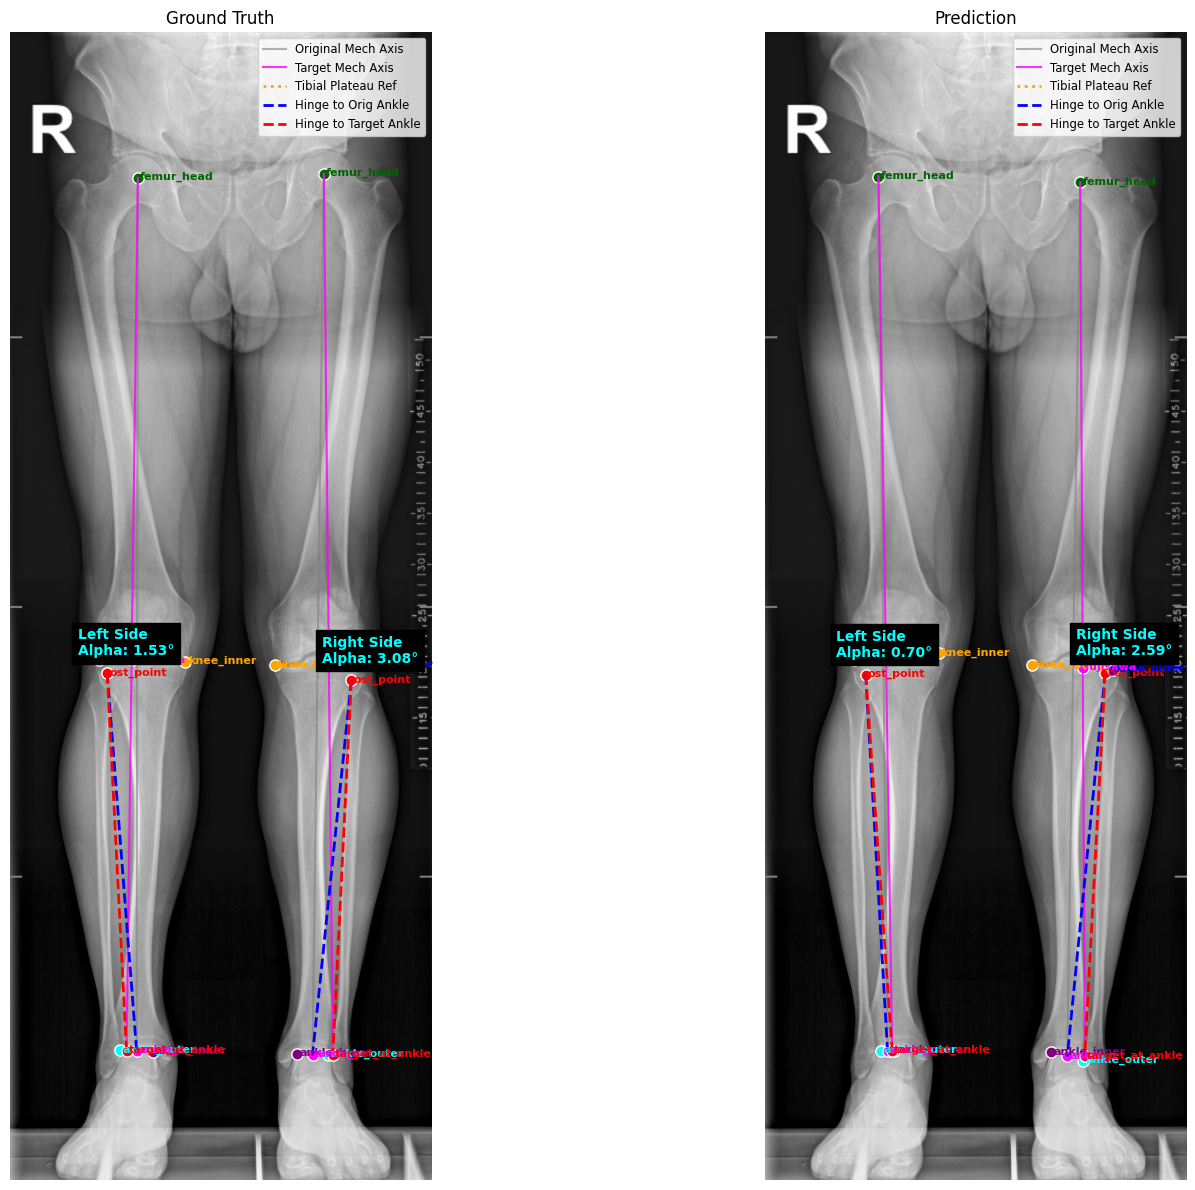

Visualized File: 13_0.png
Left Side  | GT Alpha: 1.5254°, Pred Alpha: 0.6954°, Diff: 0.8300°
Right Side | GT Alpha: 3.0790°, Pred Alpha: 2.5903°, Diff: 0.4887°


In [33]:
if eval_results:
    samples_both = [s for s in eval_results if s["res_l"] and s["res_r"]]
    sample = random.choice(samples_both) if samples_both else random.choice(eval_results)
    
    img_path = sample["img_path"]
    img = Image.open(img_path).convert("RGB")
    
    fig, (ax_gt, ax_pred) = plt.subplots(1, 2, figsize=(18, 12))
    
    def plot_hemispheres(ax, s_entry, is_gt=True):
        ax.imshow(img, cmap="gray")
        title = "Ground Truth" if is_gt else "Prediction"
        ax.set_title(title)
        
        for s_key in ["res_l", "res_r"]:
            res = s_entry[s_key]
            if not res: continue
            
            pts = res["gt_pts"] if is_gt else res["pred_pts"]
            alpha = res["gt_angle"] if is_gt else res["pred_angle"]
            side_name = res["side"]
            
            for name, p in pts.items():
                if isinstance(p, np.ndarray) and p.shape == (2,):
                    c = LANDMARK_COLORS.get(name, "magenta")
                    ax.scatter(p[0], p[1], s=65, color=c, edgecolors='white', linewidths=1)
                    ax.text(p[0]+15, p[1]+15, f"{name}", color=c, fontsize=8, weight="bold")
            
            # 1. Original Mechanical Axis: femur_head to ankle_c
            ax.plot([pts["femur_head"][0], pts["ankle_c"][0]],
                    [pts["femur_head"][1], pts["ankle_c"][1]], color='gray', linestyle='-', linewidth=1.5, alpha=0.6, label="Original Mech Axis" if s_key=="res_l" else "")
            
            # 2. Target Mechanical Axis: femur_head to target_at_ankle
            ax.plot([pts["femur_head"][0], pts["target_at_ankle"][0]],
                    [pts["femur_head"][1], pts["target_at_ankle"][1]], color='magenta', linestyle='-', linewidth=1.5, alpha=0.8, label="Target Mech Axis" if s_key=="res_l" else "")
            
            # 3. Tibial Plateau Reference Line
            ax.plot([pts["knee_inner"][0], pts["knee_outer"][0]],
                    [pts["knee_inner"][1], pts["knee_outer"][1]], color='orange', linestyle=':', linewidth=2, label="Tibial Plateau Ref" if s_key=="res_l" else "")
            
            # 4. Miniaci Hinge Correction Arc Lines (The Wedge)
            ax.plot([pts["ost_point"][0], pts["ankle_c"][0]],
                    [pts["ost_point"][1], pts["ankle_c"][1]], color='blue', linestyle='--', linewidth=2, label="Hinge to Orig Ankle" if s_key=="res_l" else "")
            ax.plot([pts["ost_point"][0], pts["target_at_ankle"][0]],
                    [pts["ost_point"][1], pts["target_at_ankle"][1]], color='red', linestyle='--', linewidth=2, label="Hinge to Target Ankle" if s_key=="res_l" else "")
                    
            ax.text(pts["ost_point"][0]-200, pts["ost_point"][1]-120, f"{side_name}\nAlpha: {alpha:.2f}°", color="cyan", fontsize=10, weight="bold", backgroundcolor="black")
            
        ax.axis("off")
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        if by_label:
            ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize='small')

    plot_hemispheres(ax_gt, sample, is_gt=True)
    plot_hemispheres(ax_pred, sample, is_gt=False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Visualized File: {sample['filename']}")
    if sample["res_l"]:
        print(f"Left Side  | GT Alpha: {sample['res_l']['gt_angle']:.4f}°, Pred Alpha: {sample['res_l']['pred_angle']:.4f}°, Diff: {abs(sample['res_l']['pred_angle']-sample['res_l']['gt_angle']):.4f}°")
    if sample["res_r"]:
        print(f"Right Side | GT Alpha: {sample['res_r']['gt_angle']:.4f}°, Pred Alpha: {sample['res_r']['pred_angle']:.4f}°, Diff: {abs(sample['res_r']['pred_angle']-sample['res_r']['gt_angle']):.4f}°")
else:
    print("No evaluation results to visualize.")